#BLOQUE 1

Primero de todo instalamos las librerías que pudieran ser de utilidad

In [1]:
!pip install astroquery
!pip install ydata_profiling
!pip install astropy
!pip install poliastro
!pip install SciPY
!pip install PlotLy
!pip install pygwalker
!pip install seaborn
!pip install numba
!pip install jplephem
!pip install Astropy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 45.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.3/399.3 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
Requested poliastro from https://files.pythonhosted.org/

In [2]:
!pip install pygwalker -q

Pygwalker es una bibloteca de pyhton que nos permite hacer gráficas arrastrando y pinchando las variables del dataframe

Realizamos la query

In [3]:
from astroquery.gaia import Gaia
from pandas import DataFrame
query = """
SELECT TOP 5000
  source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source
WHERE parallax > 5 AND parallax_over_error > 5
"""
# señal fuerte, error < 20%
job= Gaia.launch_job_async(query)
gaia_data= job.get_results().to_pandas()
gaia_data.head()


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


,source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag,bp_rp
0,4078365365086028416,280.297031,-23.435446,5.000000,0.938784,20.121367,1.466566
1,4053338796833458304,264.140622,-34.822010,5.000001,0.940663,20.159420,NaN
2,85457892001872000,42.273520,21.238497,5.000001,0.168179,18.027079,2.485622
3,6702268805824338304,274.922035,-50.977193,5.000001,0.014416,11.918877,0.967007
4,2295269559942880128,294.056501,80.953859,5.000002,0.012876,14.040513,1.676291


Información sobre los datos obtenidos:

In [4]:
gaia_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_id        5000 non-null   int64  
 1   ra               5000 non-null   float64
 2   dec              5000 non-null   float64
 3   parallax         5000 non-null   float64
 4   parallax_error   5000 non-null   float32
 5   phot_g_mean_mag  4995 non-null   float32
 6   bp_rp            4642 non-null   float32
dtypes: float32(3), float64(3), int64(1)
memory usage: 215.0 KB


In [5]:
gaia_data.columns

Index(['source_id', 'ra', 'dec', 'parallax', 'parallax_error',
       'phot_g_mean_mag', 'bp_rp'],
      dtype='object')

In [6]:
df3 = gaia_data.copy()
# eliminar valores nulos de la columna bp_rp
df3 = df3.dropna(subset=['bp_rp'])

# Filtrar los datos con 'parallax' > 5
dist200 = df3["parallax"] > 5
df3 = df3[dist200]

print(df3)

                source_id          ra        dec  parallax  parallax_error  \
0     4078365365086028416  280.297031 -23.435446  5.000000        0.938784   
2       85457892001872000   42.273520  21.238497  5.000001        0.168179   
3     6702268805824338304  274.922035 -50.977193  5.000001        0.014416   
4     2295269559942880128  294.056501  80.953859  5.000002        0.012876   
6      138914876034988672   46.378075  35.924528  5.000003        0.175373   
...                   ...         ...        ...       ...             ...   
4995  5850548551654647808  204.714070 -67.909546  5.003090        0.020754   
4996  3948397215130759808  189.818111  19.673388  5.003091        0.394636   
4997   509454864444990208   22.741707  60.024571  5.003092        0.118539   
4998  4512475473640562560  281.478486  18.430424  5.003092        0.874680   
4999  2433070871213610112  352.919620 -13.192191  5.003092        0.188059   

      phot_g_mean_mag     bp_rp  
0           20.121367  1.4665

In [7]:
df3.describe()

,source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag,bp_rp
count,4.642000e+03,4642.000000,4642.000000,4642.000000,4642.000000,4642.000000,4642.000000
mean,3.736858e+18,202.990923,-5.901629,5.001538,0.327303,17.195969,2.142843
std,1.930271e+18,97.699836,38.575261,0.000892,0.324638,2.780424,0.782121
min,4.221781e+14,0.205249,-87.387507,5.000000,0.008718,4.752333,-0.412222
25%,2.036275e+18,117.177300,-34.740288,5.000776,0.049623,15.841830,1.547030
50%,4.062484e+18,236.825692,-11.553050,5.001507,0.163087,17.914179,2.279344
75%,5.515250e+18,277.352074,23.018255,5.002326,0.628896,19.386435,2.781893
max,6.917036e+18,359.953709,89.280562,5.003092,0.999659,20.799561,4.181353


Calculamos distancia y magnitud absoluta

In [8]:
d = 1000/ df3["parallax"]
print(d)

0       199.999997
2       199.999946
3       199.999945
4       199.999907
6       199.999896
           ...    
4995    199.876465
4996    199.876436
4997    199.876413
4998    199.876401
4999    199.876384
Name: parallax, Length: 4642, dtype: float64


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
M = df3["phot_g_mean_mag"] + 5 -(5*np.log10(d))
print(M)

0       13.616217
2       11.521929
3        5.413727
4        7.535363
6       11.692512
          ...    
4995     8.448596
4996    11.674224
4997    11.484777
4998    11.427032
4999    11.349508
Length: 4642, dtype: float64


Implementmos los datos en el csv:

In [10]:
df3["Abs_Mag"] = M
df3["distancia"] = d
print(df3)

                source_id          ra        dec  parallax  parallax_error  \
0     4078365365086028416  280.297031 -23.435446  5.000000        0.938784   
2       85457892001872000   42.273520  21.238497  5.000001        0.168179   
3     6702268805824338304  274.922035 -50.977193  5.000001        0.014416   
4     2295269559942880128  294.056501  80.953859  5.000002        0.012876   
6      138914876034988672   46.378075  35.924528  5.000003        0.175373   
...                   ...         ...        ...       ...             ...   
4995  5850548551654647808  204.714070 -67.909546  5.003090        0.020754   
4996  3948397215130759808  189.818111  19.673388  5.003091        0.394636   
4997   509454864444990208   22.741707  60.024571  5.003092        0.118539   
4998  4512475473640562560  281.478486  18.430424  5.003092        0.874680   
4999  2433070871213610112  352.919620 -13.192191  5.003092        0.188059   

      phot_g_mean_mag     bp_rp    Abs_Mag   distancia  
0     

Realizamos las gráficas

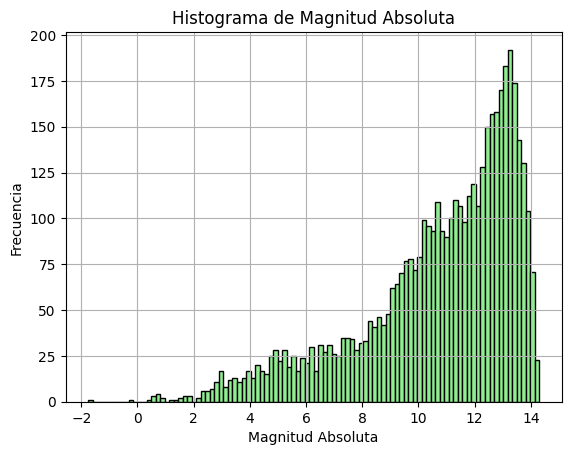

In [11]:
df3.hist(column="Abs_Mag", color="lightgreen", edgecolor="black", bins=100)
plt.title("Histograma de Magnitud Absoluta")
plt.xlabel("Magnitud Absoluta")
plt.ylabel("Frecuencia")
plt.show()

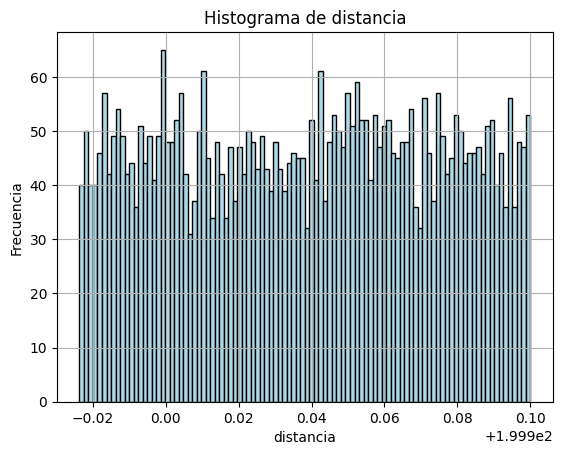

In [12]:
df3.hist(column="distancia", color="lightblue", edgecolor="black", bins =100)
plt.title("Histograma de distancia")
plt.xlabel("distancia")
plt.ylabel("Frecuencia")
plt.show()

Hacemos un mapa de calor de correlación de variables:

<Axes: >

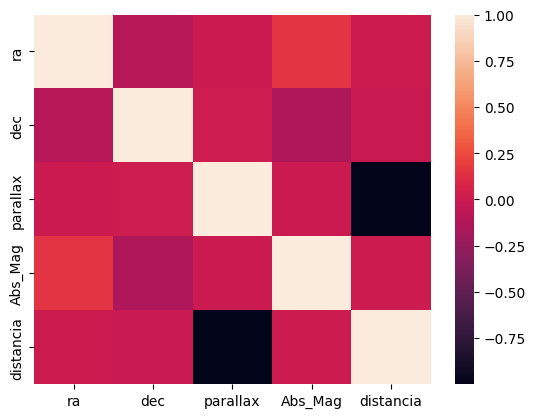

In [13]:
sns.heatmap(df3.select_dtypes([np.float64]).corr())

La correlación más grande es la de distancia y paralaje, esto se debe a que cuanto más alejado esté el objeto menos paralaje se aprecia

Representamos en un gráfico de dispersión la ascensión recta vs declinación:

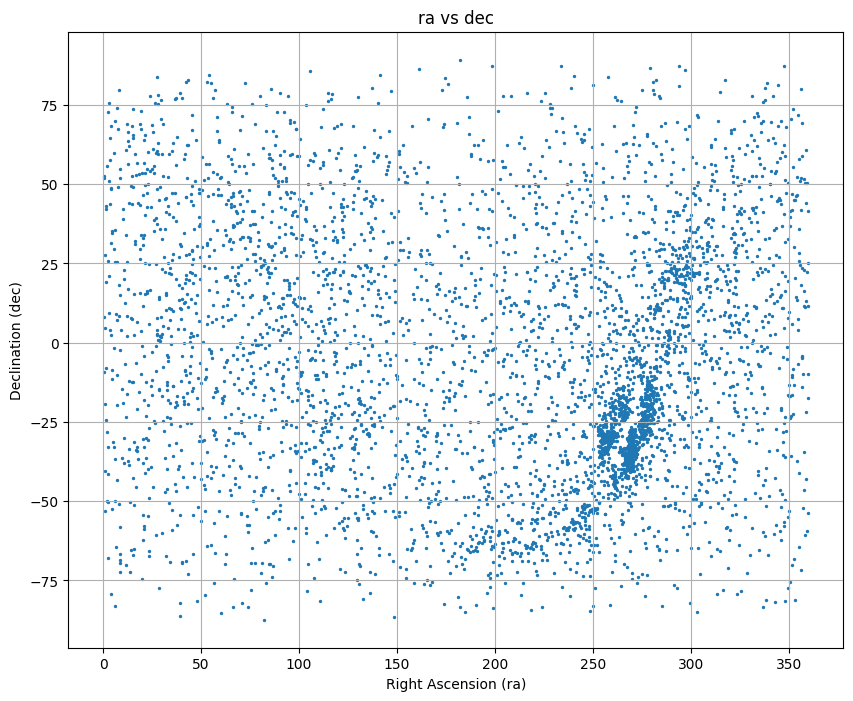

In [14]:
plt.figure(figsize=(10, 8))
plt.scatter(df3['ra'], df3['dec'], s=2)
plt.xlabel('Right Ascension (ra)')
plt.ylabel('Declination (dec)')
plt.title('ra vs dec')
plt.grid(True)
plt.show()

Comparamos las gráficas y los diagramas del estudio con el que realiza ydata_profiling:

In [15]:
from ydata_profiling import ProfileReport
report = ProfileReport(df3)
report.to_file("report.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 26.62it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
report

Output hidden; open in https://colab.research.google.com to view.

# BLOQUE 2

Empezamos haciendo la query:

In [17]:
from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive
from astropy.table import Table
import pandas as pd

from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
exo_table=NasaExoplanetArchive.query_criteria(table="pscomppars", select="top 5000 pl_name, pl_orbper, pl_rade, pl_bmasse, st_teff, st_rad, st_mass")

# Convert to pandas DataFrame
df = exo_table.to_pandas()
print(df)

/tmp/ipython-input-3427373024.py:1: DeprecationWarning: the ``nasa_exoplanet_archive`` module has been moved to astroquery.ipac.nexsci.nasa_exoplanet_archive, please update your imports.
  from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive


          pl_name   pl_orbper   pl_rade  pl_bmasse  st_teff  st_rad  st_mass
0      CoRoT-10 b   13.240600  10.87000   874.0000   5075.0   0.790    0.890
1      CoRoT-11 b    2.994330  16.03000   740.5100   6440.0   1.370    1.270
2      CoRoT-13 b    4.035190   9.92000   415.7040   5945.0   1.010    1.090
3      CoRoT-12 b    2.828042  16.14000   291.4380   5675.0   1.116    1.078
4      CoRoT-14 b    1.512140  12.22000  2415.4000   6035.0   1.210    1.130
...           ...         ...       ...        ...      ...     ...      ...
4995   HAT-P-21 b    4.124480  12.44199  1547.8321   5588.0   1.210    1.240
4996   HD 10647 b  989.200000  13.80000   298.7500   6218.0   1.100    1.110
4997   HAT-P-23 b    1.212884  15.33400   664.2370   5905.0   1.203    1.130
4998  HD 103197 b   47.840000   5.83000    28.6047   5250.0   0.880    0.800
4999  HD 104067 b   55.851000   9.20000    62.1000   4952.0   0.780    0.820

[5000 rows x 7 columns]


In [18]:
# hacemos copia de los datos para trabajar mejor
df1 = df.copy()
df1.describe()

,pl_orbper,pl_rade,pl_bmasse,st_teff,st_rad,st_mass
count,4.731000e+03,4981.000000,4973.000000,4766.000000,4749.000000,4994.000000
mean,9.034601e+04,5.651943,384.083563,5421.673210,1.486526,0.934653
std,5.847250e+06,5.269864,1110.703591,1887.104125,3.831425,0.402492
min,9.070629e-02,0.309800,0.020000,575.000000,0.011500,0.014700
25%,4.292049e+00,1.790000,4.040000,4914.250000,0.770000,0.770000
50%,1.099470e+01,2.790000,8.880000,5555.000000,0.950000,0.940000
75%,3.892856e+01,11.430000,165.260000,5903.000000,1.238000,1.084300
max,4.020000e+08,77.342100,12651.500000,57000.000000,88.475000,10.940000


Información relativa al dataframe:

In [19]:
df1.head()

,pl_name,pl_orbper,pl_rade,pl_bmasse,st_teff,st_rad,st_mass
0,CoRoT-10 b,13.240600,10.87,874.000,5075.0,0.790,0.890
1,CoRoT-11 b,2.994330,16.03,740.510,6440.0,1.370,1.270
2,CoRoT-13 b,4.035190,9.92,415.704,5945.0,1.010,1.090
3,CoRoT-12 b,2.828042,16.14,291.438,5675.0,1.116,1.078
4,CoRoT-14 b,1.512140,12.22,2415.400,6035.0,1.210,1.130


In [20]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pl_name    5000 non-null   object 
 1   pl_orbper  4731 non-null   float64
 2   pl_rade    4981 non-null   float64
 3   pl_bmasse  4973 non-null   float64
 4   st_teff    4766 non-null   float64
 5   st_rad     4749 non-null   float64
 6   st_mass    4994 non-null   float64
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [21]:
df1 = df1.dropna()
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4664 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pl_name    4664 non-null   object 
 1   pl_orbper  4664 non-null   float64
 2   pl_rade    4664 non-null   float64
 3   pl_bmasse  4664 non-null   float64
 4   st_teff    4664 non-null   float64
 5   st_rad     4664 non-null   float64
 6   st_mass    4664 non-null   float64
dtypes: float64(6), object(1)
memory usage: 291.5+ KB


Mediante Histogrmas, estudiamos las propiedades de las estreas y de os planetas:

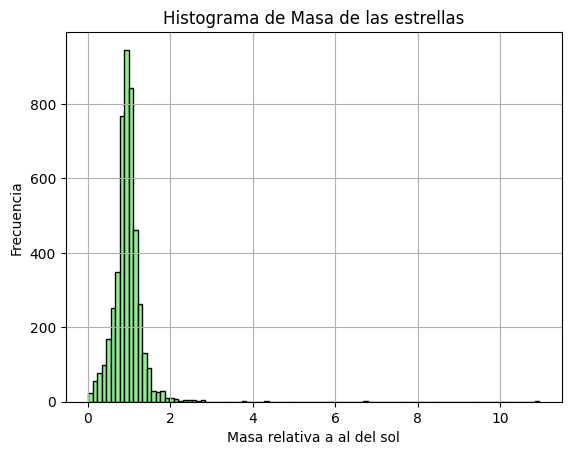

In [22]:
import matplotlib.pyplot as plt
df1.hist(column="st_mass", color="lightgreen", edgecolor="black", bins=100)
plt.title("Histograma de Masa de las estrellas")
plt.xlabel("Masa relativa a al del sol")
plt.ylabel("Frecuencia")
plt.show()

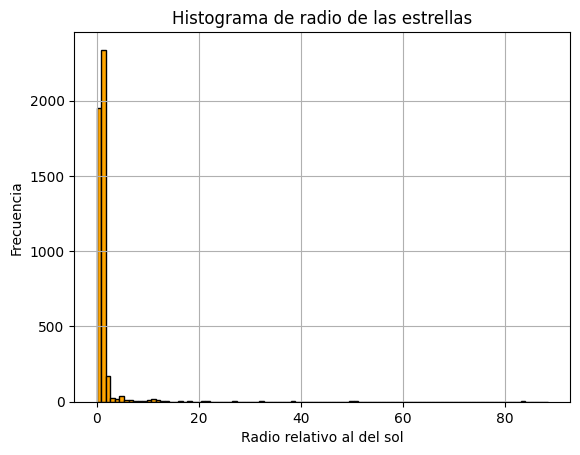

In [23]:
df1.hist(column="st_rad", color="orange", edgecolor="black", bins=100)
plt.title("Histograma de radio de las estrellas")
plt.xlabel("Radio relativo al del sol")
plt.ylabel("Frecuencia")
plt.show()

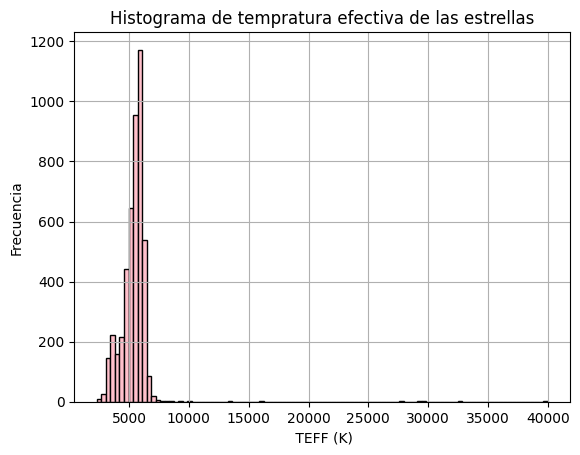

In [24]:
df1.hist(column="st_teff", color="pink", edgecolor="black", bins=100)
plt.title("Histograma de tempratura efectiva de las estrellas")
plt.xlabel(" TEFF (K)")
plt.ylabel("Frecuencia")
plt.show()

La mayoría de las estrellas son del mismo tamaño que el del sol, vamos a ver los tamaños de los planetas

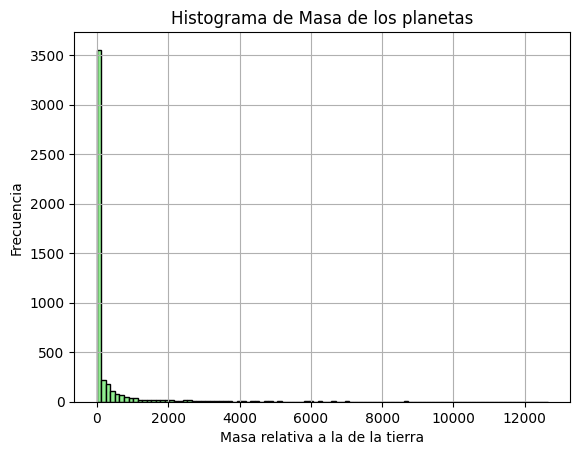

In [25]:
df1.hist(column="pl_bmasse", color="lightgreen", edgecolor="black", bins=100)
plt.title("Histograma de Masa de los planetas")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

Calculando media y mediana en masa de los planetas, se puede apreciar perfectamente como los planetas gigantes gaseosos arrastran la media de la masa de los planetas a valores más altos. Vamos a intentar agrupar los datos de los planetas rocosos por un lado y los de los gigantes gaseosos por otro

In [26]:
median_value = df1['pl_bmasse'].median()
print(f"The median of 'pl_bmasse' is: {median_value}")

The median of 'pl_bmasse' is: 8.25


In [27]:
average_value = df1['pl_bmasse'].mean()
print(f"The average of 'pl_bmasse' is: {average_value}")

The average of 'pl_bmasse' is: 313.5134830598757


Vamos a separar el dataframe en dos grupos, rocosos y gigantes y tratarlos de forma separada. Vamos a establecer que 5 masas terrestres sea el límite para considerar rocoso al planeta, todo lo que caiga fuera de ese valor será gigante gaseoso

In [28]:
rocosos = df1[df1['pl_bmasse'] <= 5]
gigantes = df1[df1['pl_bmasse'] > 5]
print(rocosos)
print(gigantes)

            pl_name  pl_orbper   pl_rade  pl_bmasse  st_teff    st_rad  \
66         KOI-55 b   0.240104  0.759000    0.44000  27730.0  0.203000   
75      Kepler-32 e   2.896000  1.500000    4.08181   3900.0  0.530000   
81      Kepler-33 d  21.775960  5.350000    3.91000   5904.0  1.820000   
82      Kepler-33 b   5.667930  1.740000    3.68000   5904.0  1.820000   
93    Kepler-1157 b   4.457432  1.090000    1.32000   4679.0  0.710000   
...             ...        ...       ...        ...      ...       ...   
4966       K2-165 c   4.382745  1.554090    3.03000   5185.0  0.803827   
4967       K2-175 b   9.525988  2.038037    4.81000   5909.0  1.420038   
4968       K2-176 b   5.329439  1.490901    2.83000   5428.0  0.864160   
4972       K2-185 b  10.616384  1.150000    1.60000   5788.0  0.940000   
4989   Kepler-763 d   6.503270  1.670000    3.43000   4999.0  0.843000   

       st_mass  
66    0.496000  
75    0.580000  
81    1.291000  
82    1.291000  
93    0.760000  
...      

Dado que la media de original de los planetas nos ha dado 322 masas solares, estudiaremos con más detalles los planetas gaseosos, ya que puede haber más subdivisiones.
Empezamos por los rocosos:

## PLANETAS ROCOSOS

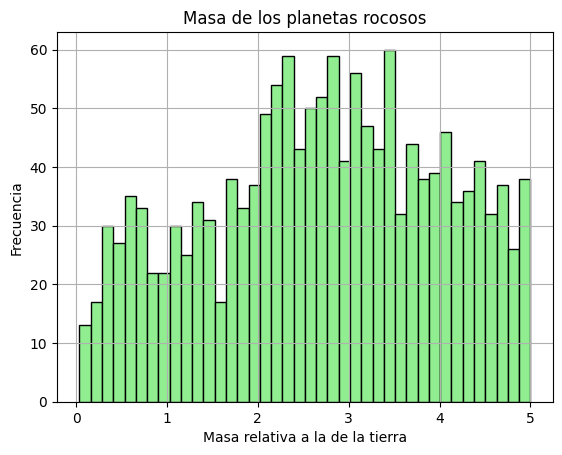

In [29]:
rocosos.hist(column="pl_bmasse", color="lightgreen", edgecolor="black", bins=40)
plt.title("Masa de los planetas rocosos")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

La mayoría de la masa de los rocosos se encuentra entre 2 y 3 masas terrestres, lo que se denominan "supertierras". Vamos a ver sus periodos orbitales

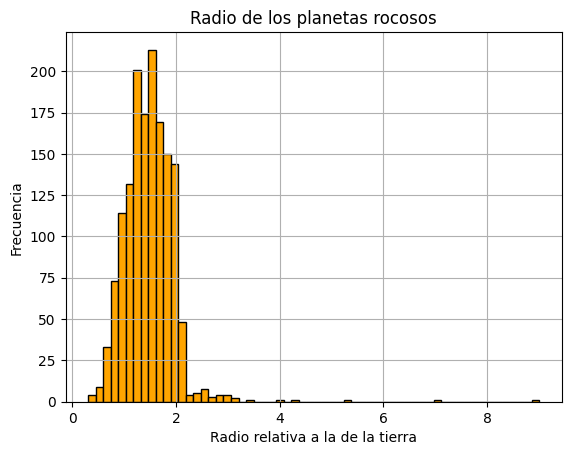

In [30]:
rocosos.hist(column="pl_rade", color="orange", edgecolor="black", bins=60)
plt.title("Radio de los planetas rocosos")
plt.xlabel("Radio relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

Los datos del radio nos dan distribuciones similares a las de la masa, por lo que concluimos que los planetas rocosos tienen una densidad similar a la de la tierra, ya que la proporcion ( masa/radio) se conserva. De todas formas, hay planetas con masas muy pequeñas y radios grandes

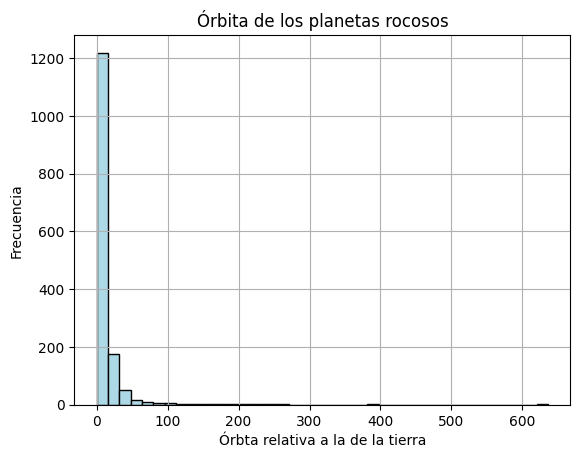

In [31]:
rocosos.hist(column="pl_orbper", color="lightblue", edgecolor="black", bins=40)
plt.title("Órbita de los planetas rocosos")
plt.xlabel("Órbta relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

Vamos a ver la media y mediana de los valores de órbita par comprobar las desviaciones.

In [32]:
mean_value = rocosos['pl_orbper'].mean()
print(f"La media de 'pl_orbper' es: {mean_value}")

La media de 'pl_orbper' es: 13.022010040542


In [33]:
median_value = rocosos['pl_orbper'].median()
print(f"La mediana de 'pl_orbper' es: {median_value}")

La mediana de 'pl_orbper' es: 6.40050309


Como con las masas, nos encontramos con muchos planetas que orbítan la estrella muy cerca, pero pocos que la orbítan muy lejos. Vamos a dividirlos en planetas de órbita larga y orbita corta. Establecemos 3 veces la órbita como órbita "corta" y el resto como órbita "larga".

In [34]:
roc_cor = rocosos[rocosos['pl_orbper'] <= 3]
roc_lar = rocosos[rocosos['pl_orbper'] > 3]
print(roc_cor)
print(roc_lar)

            pl_name  pl_orbper  pl_rade  pl_bmasse  st_teff  st_rad   st_mass
66         KOI-55 b   0.240104    0.759    0.44000  27730.0   0.203  0.496000
75      Kepler-32 e   2.896000    1.500    4.08181   3900.0   0.530  0.580000
95      Kepler-98 b   1.541680    1.990    3.55000   5539.0   1.110  0.990000
98    Kepler-1228 b   0.577370    1.540    2.99000   5063.0   0.740  0.780000
104   Kepler-1323 b   0.929907    1.520    2.92000   6169.0   1.400  1.180000
...             ...        ...      ...        ...      ...     ...       ...
4921       K2-233 b   2.467583    1.315    2.40000   4796.0   0.710  0.790000
4948       K2-187 b   0.774010    1.200    1.87000   5438.0   0.830  0.966999
4950       K2-189 b   2.588120    1.403    2.55000   5442.0   0.879  0.850000
4963       K2-157 b   0.365258    0.935    1.14000   5334.0   0.860  0.890000
4965       K2-156 b   0.813143    1.100    1.37000   4460.0   0.620  0.660000

[360 rows x 7 columns]
            pl_name  pl_orbper   pl_rade

332 planetas de órbita corta, 1113 de órbita larga. vamos a estudiar primero los de órbita corta, después los de órbita larga.

###ORBITA CORTA

#### HISTOGRAMAS DE MASA, RADIO Y PERIODO ORBÍTAL

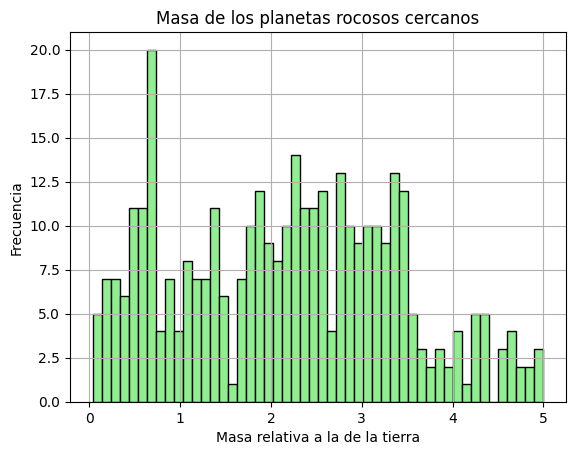

In [35]:
roc_cor.hist(column="pl_bmasse", color="lightgreen", edgecolor="black", bins=50)
plt.title("Masa de los planetas rocosos cercanos")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

Mayoría de los planetas tienen una masa entre 2 y 3 veces la de a tierra

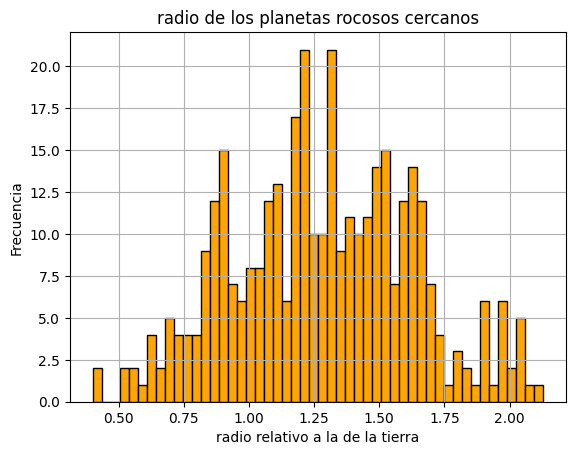

In [36]:
roc_cor.hist(column="pl_rade", color="orange", edgecolor="black", bins=50)
plt.title("radio de los planetas rocosos cercanos")
plt.xlabel("radio relativo a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

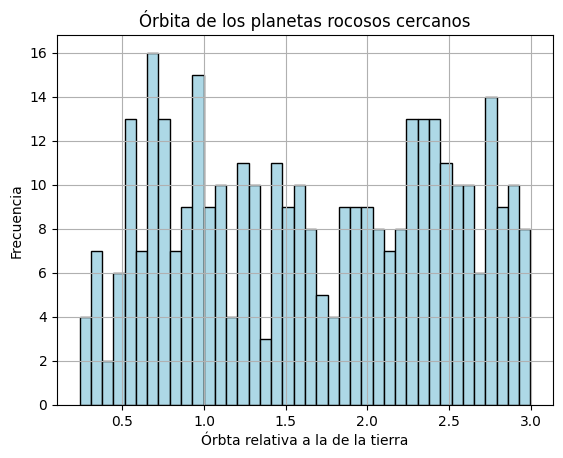

In [37]:
roc_cor.hist(column="pl_orbper", color="lightblue", edgecolor="black", bins=40)
plt.title("Órbita de los planetas rocosos cercanos")
plt.xlabel("Órbta relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

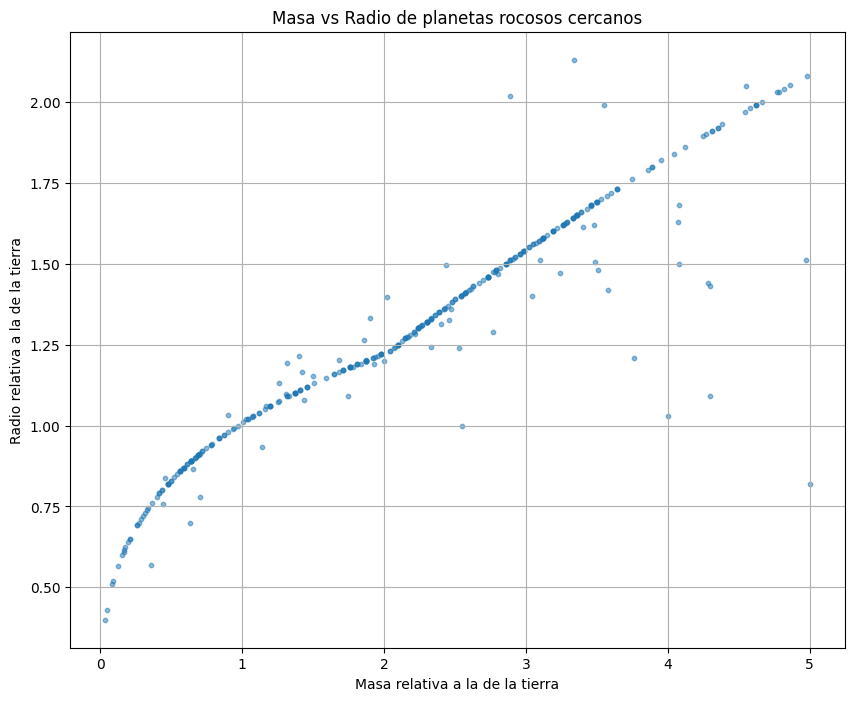

In [38]:
plt.figure(figsize=(10, 8))
plt.scatter(roc_cor['pl_bmasse'], roc_cor['pl_rade'], s=10, alpha=0.5)
plt.title("Masa vs Radio de planetas rocosos cercanos")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Radio relativa a la de la tierra")
plt.grid(True)
plt.show()

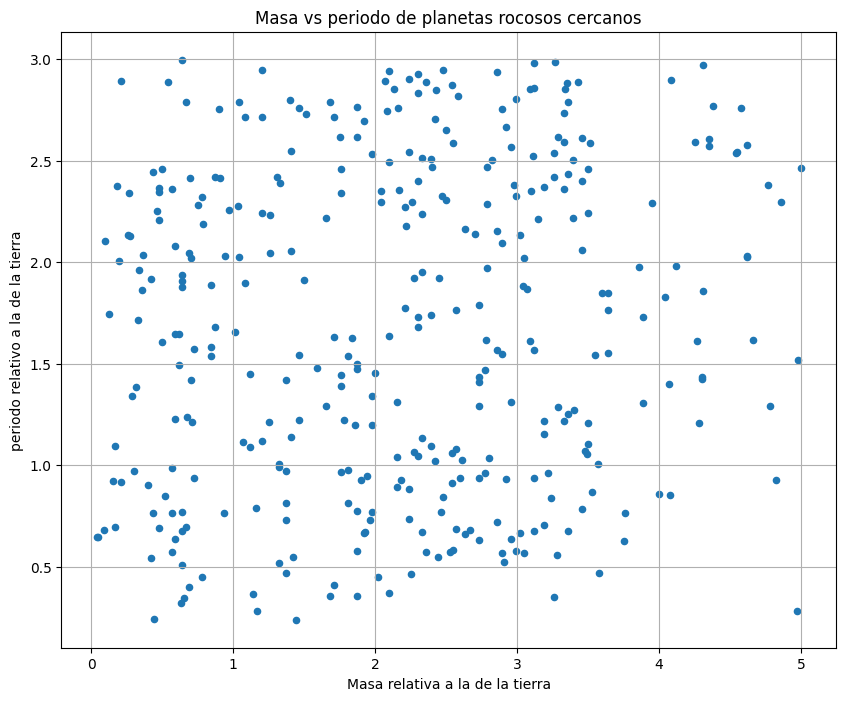

In [39]:
plt.figure(figsize=(10, 8))
plt.scatter(roc_cor['pl_bmasse'], roc_cor['pl_orbper'], s=20, alpha=1)
plt.title("Masa vs periodo de planetas rocosos cercanos")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("periodo relativo a la de la tierra")
plt.grid(True)
plt.show()

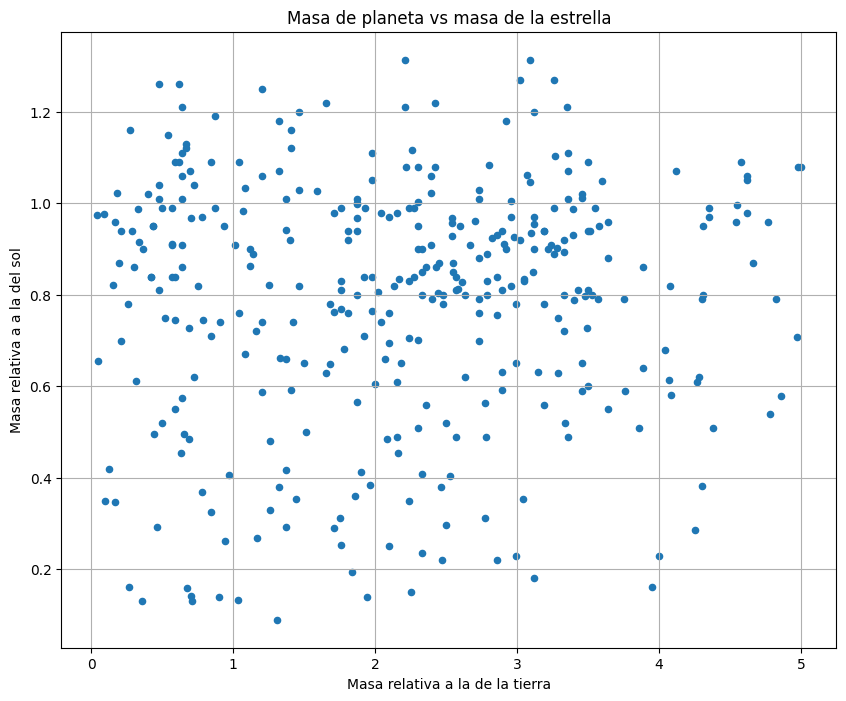

In [40]:
plt.figure(figsize=(10, 8))
plt.scatter(roc_cor['pl_bmasse'], roc_cor['st_mass'], s=20, alpha=1)
plt.title("Masa de planeta vs masa de la estrella")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Masa relativa a a la del sol")
plt.grid(True)
plt.show()

###ÓRBITA LARGA

##### HISTOGRAMA DE MASA, RADIO Y ÓRBITA

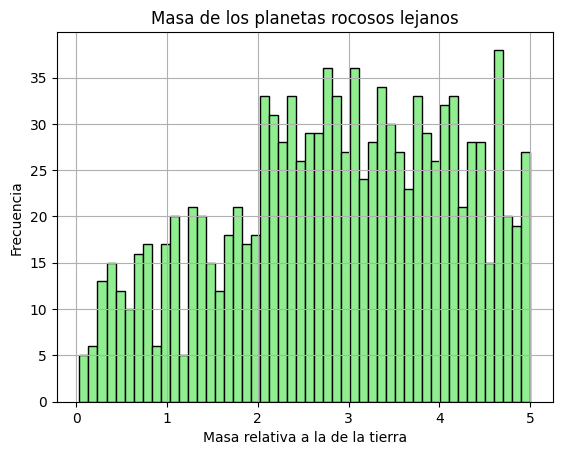

In [41]:
roc_lar.hist(column="pl_bmasse", color="lightgreen", edgecolor="black", bins=50)
plt.title("Masa de los planetas rocosos lejanos")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

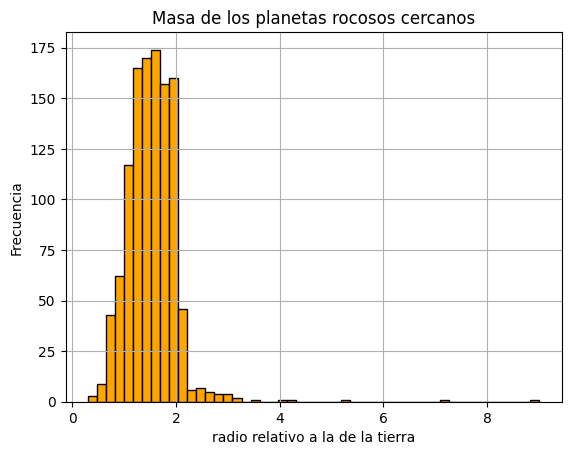

In [42]:
roc_lar.hist(column="pl_rade", color="orange", edgecolor="black", bins=50)
plt.title("Masa de los planetas rocosos cercanos")
plt.xlabel("radio relativo a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

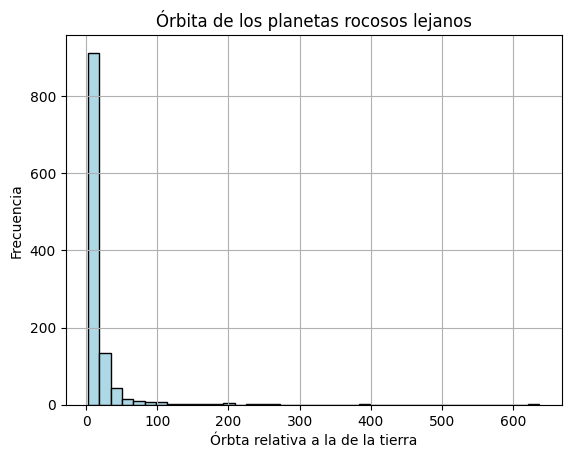

In [43]:
roc_lar.hist(column="pl_orbper", color="lightblue", edgecolor="black", bins=40)
plt.title("Órbita de los planetas rocosos lejanos")
plt.xlabel("Órbta relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

La mayoría de los planetas rocosos de órbita lejana tienen una distancía de órbita de alrederor de 20 unidades astronóicas, por lo que los datos de órbitas tan lejanas se pueden descartar, al no ser signficativos:

In [44]:
roc_lar_filtered = roc_lar[roc_lar['pl_orbper'] <= 120]
print(roc_lar_filtered)

            pl_name  pl_orbper   pl_rade  pl_bmasse  st_teff    st_rad  \
81      Kepler-33 d  21.775960  5.350000       3.91   5904.0  1.820000   
82      Kepler-33 b   5.667930  1.740000       3.68   5904.0  1.820000   
93    Kepler-1157 b   4.457432  1.090000       1.32   4679.0  0.710000   
96     Kepler-793 b   4.241536  1.370000       2.45   5745.0  0.970000   
100   Kepler-1114 b  14.974357  1.350000       2.39   5374.0  0.830000   
...             ...        ...       ...        ...      ...       ...   
4966       K2-165 c   4.382745  1.554090       3.03   5185.0  0.803827   
4967       K2-175 b   9.525988  2.038037       4.81   5909.0  1.420038   
4968       K2-176 b   5.329439  1.490901       2.83   5428.0  0.864160   
4972       K2-185 b  10.616384  1.150000       1.60   5788.0  0.940000   
4989   Kepler-763 d   6.503270  1.670000       3.43   4999.0  0.843000   

       st_mass  
81    1.291000  
82    1.291000  
93    0.760000  
96    0.980000  
100   0.870000  
...      

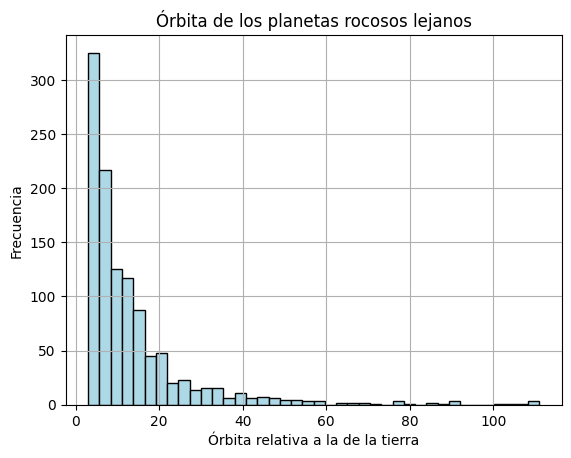

In [45]:
roc_lar_filtered.hist(column="pl_orbper", color="lightblue", edgecolor="black", bins=40)
plt.title("Órbita de los planetas rocosos lejanos")
plt.xlabel("Órbita relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

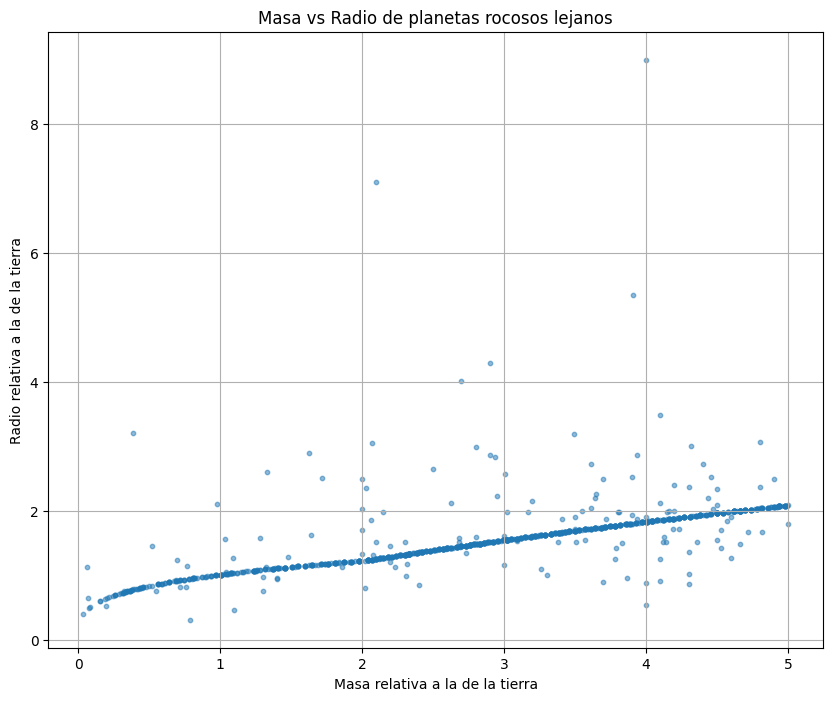

In [46]:
plt.figure(figsize=(10, 8))
plt.scatter(roc_lar['pl_bmasse'], roc_lar['pl_rade'], s=10, alpha=0.5)
plt.title("Masa vs Radio de planetas rocosos lejanos")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Radio relativa a la de la tierra")
plt.grid(True)
plt.show()

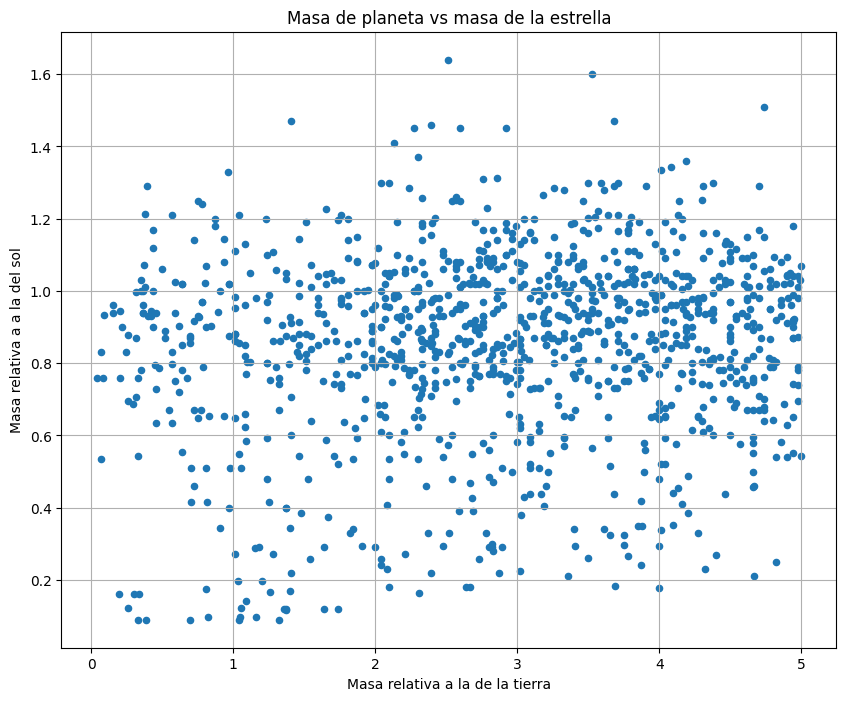

In [47]:
plt.figure(figsize=(10, 8))
plt.scatter(roc_lar['pl_bmasse'], roc_lar['st_mass'], s=20, alpha=1)
plt.title("Masa de planeta vs masa de la estrella")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Masa relativa a a la del sol")
plt.grid(True)
plt.show()

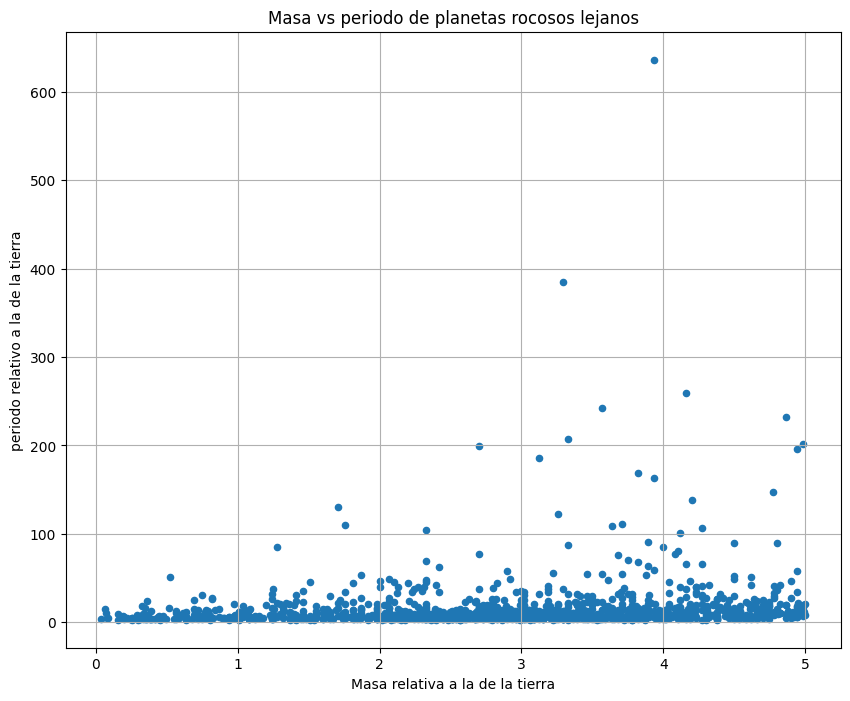

In [48]:
plt.figure(figsize=(10, 8))
plt.scatter(roc_lar['pl_bmasse'], roc_lar['pl_orbper'], s=20, alpha=1)
plt.title("Masa vs periodo de planetas rocosos lejanos")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("periodo relativo a la de la tierra")
plt.grid(True)
plt.show()

##PLANETAS GASESOSOS

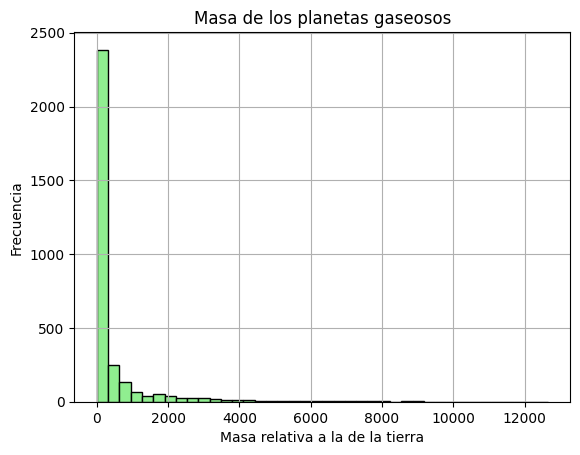

In [49]:
gigantes.hist(column="pl_bmasse", color="lightgreen", edgecolor="black", bins=40)
plt.title("Masa de los planetas gaseosos")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

En los planetas gaseosos gigantes la masa oscila mucho más que en los rocososos. Vamos a buscar en el resto de parámetros donde podemos hacer el cribado

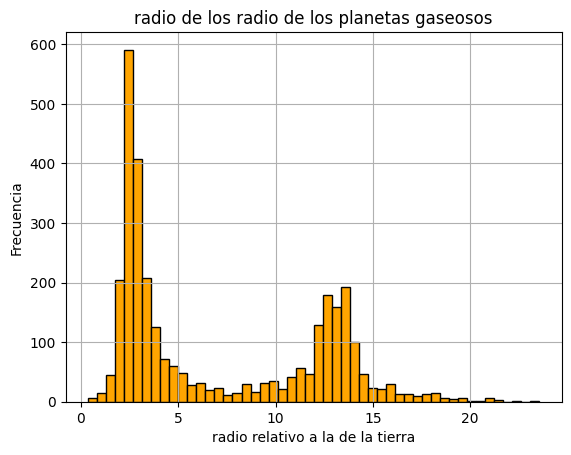

In [50]:
gigantes.hist(column="pl_rade", color="orange", edgecolor="black", bins=50)
plt.title("radio de los radio de los planetas gaseosos")
plt.xlabel("radio relativo a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

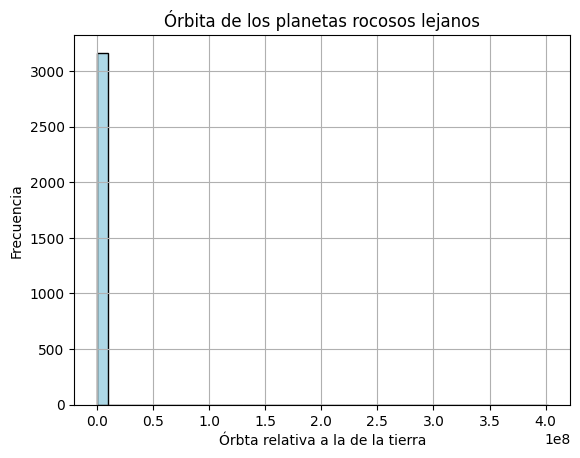

In [51]:
gigantes.hist(column="pl_orbper", color="lightblue", edgecolor="black", bins=40)
plt.title("Órbita de los planetas rocosos lejanos")
plt.xlabel("Órbta relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

Vamos a cribar ese dato de 10^6 ya que nos está desplando toda la media:

In [52]:
gas_fil = gigantes[gigantes['pl_orbper'] <= 300]
print(gas_fil)

          pl_name  pl_orbper   pl_rade  pl_bmasse  st_teff  st_rad  st_mass
0      CoRoT-10 b  13.240600  10.87000   874.0000   5075.0   0.790    0.890
1      CoRoT-11 b   2.994330  16.03000   740.5100   6440.0   1.370    1.270
2      CoRoT-13 b   4.035190   9.92000   415.7040   5945.0   1.010    1.090
3      CoRoT-12 b   2.828042  16.14000   291.4380   5675.0   1.116    1.078
4      CoRoT-14 b   1.512140  12.22000  2415.4000   6035.0   1.210    1.130
...           ...        ...       ...        ...      ...     ...      ...
4994   HAT-P-22 b   3.212220  12.89035   785.0401   5302.0   1.110    1.130
4995   HAT-P-21 b   4.124480  12.44199  1547.8321   5588.0   1.210    1.240
4997   HAT-P-23 b   1.212884  15.33400   664.2370   5905.0   1.203    1.130
4998  HD 103197 b  47.840000   5.83000    28.6047   5250.0   0.880    0.800
4999  HD 104067 b  55.851000   9.20000    62.1000   4952.0   0.780    0.820

[2658 rows x 7 columns]


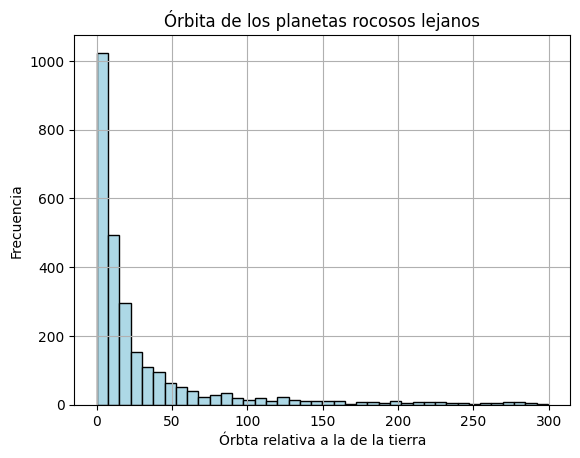

In [53]:
gas_fil.hist(column="pl_orbper", color="lightblue", edgecolor="black", bins=40)
plt.title("Órbita de los planetas rocosos lejanos")
plt.xlabel("Órbta relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

In [54]:
50/6

8.333333333333334

La grán mayoría de los gaeosos se encuentran entre 8 y 16 veces la órbita de la tierra, así que vamos a estudiar los planetas de entre 1 y 50 veces la órbita de la tierra

In [55]:
gas_fil_2 = gigantes[gigantes['pl_orbper'] <= 50]
print(gas_fil_2)

          pl_name  pl_orbper   pl_rade  pl_bmasse  st_teff  st_rad  st_mass
0      CoRoT-10 b  13.240600  10.87000   874.0000   5075.0   0.790    0.890
1      CoRoT-11 b   2.994330  16.03000   740.5100   6440.0   1.370    1.270
2      CoRoT-13 b   4.035190   9.92000   415.7040   5945.0   1.010    1.090
3      CoRoT-12 b   2.828042  16.14000   291.4380   5675.0   1.116    1.078
4      CoRoT-14 b   1.512140  12.22000  2415.4000   6035.0   1.210    1.130
...           ...        ...       ...        ...      ...     ...      ...
4993     GJ 433 b   7.370500   2.33000     6.0430   3461.0   0.500    0.480
4994   HAT-P-22 b   3.212220  12.89035   785.0401   5302.0   1.110    1.130
4995   HAT-P-21 b   4.124480  12.44199  1547.8321   5588.0   1.210    1.240
4997   HAT-P-23 b   1.212884  15.33400   664.2370   5905.0   1.203    1.130
4998  HD 103197 b  47.840000   5.83000    28.6047   5250.0   0.880    0.800

[2213 rows x 7 columns]


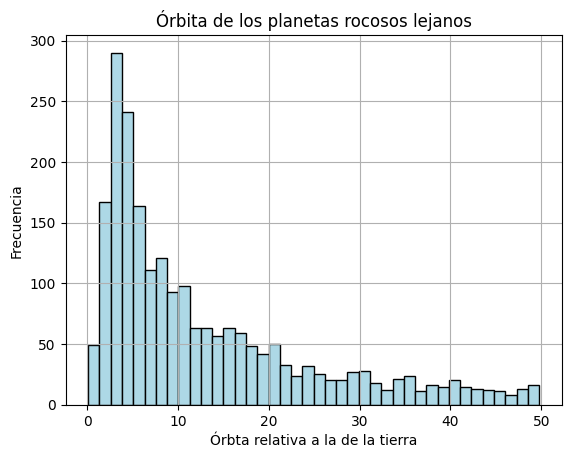

In [56]:
gas_fil_2.hist(column="pl_orbper", color="lightblue", edgecolor="black", bins=40)
plt.title("Órbita de los planetas rocosos lejanos")
plt.xlabel("Órbta relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

Tras el 2º cribado, podemos observar que las órbitas más típicas están en alredeor de 5~10 órbitas terrestres, lo que encaja con nuestro propio sistema solar, ya que las órbits de jupiter y saturno se encuentran en esa franja.

Vamos ahora a filtrar las masas basandonos en los datos obtenidos en las demás gráficas: en las órbitas podemos apreciar que la mayoría están entre 1 y 15 UA, y en el radio, se aprecian 2 frupos diferenciados: los de radio de 2|5 veces el radio y los de 10|15 veces, lo que nos indíca que hay planetas tipo jupiter saturno y los planetas tipo urano neptuno

In [57]:
gas_mas = gigantes[gigantes['pl_bmasse'] <= 50]
print(gas_fil_2)

          pl_name  pl_orbper   pl_rade  pl_bmasse  st_teff  st_rad  st_mass
0      CoRoT-10 b  13.240600  10.87000   874.0000   5075.0   0.790    0.890
1      CoRoT-11 b   2.994330  16.03000   740.5100   6440.0   1.370    1.270
2      CoRoT-13 b   4.035190   9.92000   415.7040   5945.0   1.010    1.090
3      CoRoT-12 b   2.828042  16.14000   291.4380   5675.0   1.116    1.078
4      CoRoT-14 b   1.512140  12.22000  2415.4000   6035.0   1.210    1.130
...           ...        ...       ...        ...      ...     ...      ...
4993     GJ 433 b   7.370500   2.33000     6.0430   3461.0   0.500    0.480
4994   HAT-P-22 b   3.212220  12.89035   785.0401   5302.0   1.110    1.130
4995   HAT-P-21 b   4.124480  12.44199  1547.8321   5588.0   1.210    1.240
4997   HAT-P-23 b   1.212884  15.33400   664.2370   5905.0   1.203    1.130
4998  HD 103197 b  47.840000   5.83000    28.6047   5250.0   0.880    0.800

[2213 rows x 7 columns]


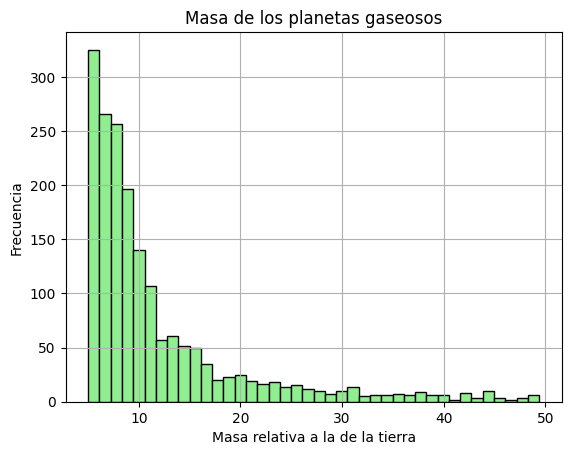

In [58]:
gas_mas.hist(column="pl_bmasse", color="lightgreen", edgecolor="black", bins=40)
plt.title("Masa de los planetas gaseosos")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Frecuencia")
plt.show()

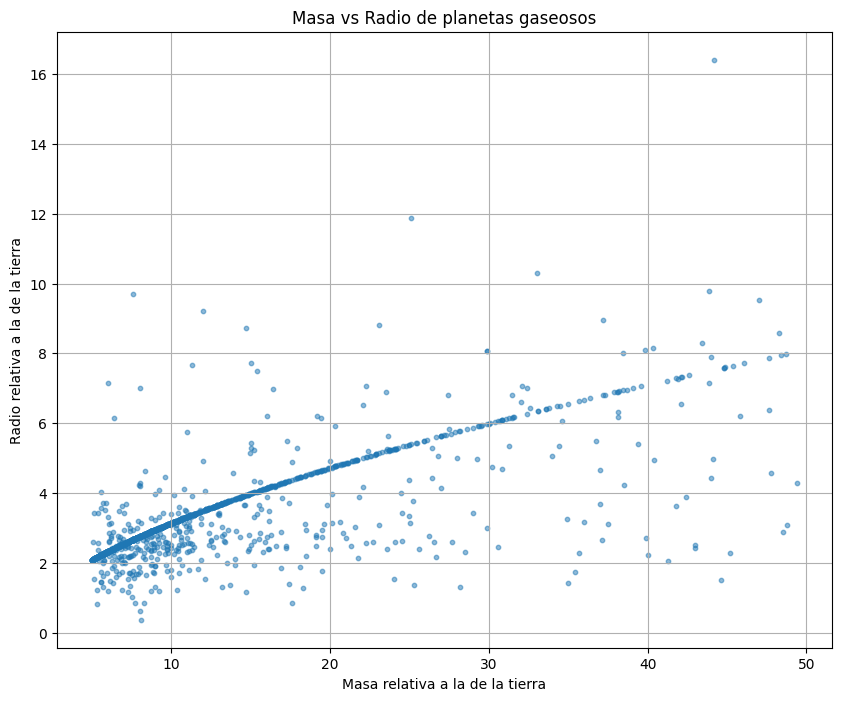

In [59]:
plt.figure(figsize=(10, 8))
plt.scatter(gas_mas['pl_bmasse'], gas_mas['pl_rade'], s=10, alpha=0.5)
plt.title("Masa vs Radio de planetas gaseosos")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Radio relativa a la de la tierra")
plt.grid(True)
plt.show()

Como la relación de masa y radio es muy similar, vamos a intentar calcular la densidad media de los planetas gaseosos:

In [60]:
densidad = (gas_mas['pl_bmasse']*(6*(10**24)) /(np.pi * (4/3)*(gas_mas['pl_rade']*6378000)**3))
print(densidad)

9        2997.311683
12        947.505803
13        886.343937
15      10532.080073
16        539.949106
            ...     
4982     2046.110461
4986     1962.473553
4992     1132.598307
4993     2637.508862
4998      796.967900
Length: 1835, dtype: float64


In [61]:
densidad.mean()

np.float64(3621.8288609437145)

La densidad media es mucho menor que la de los planetas rocosos, y tiene sentido, ya que la mayor parte de la masa de estos planetas está compuesta por gas.

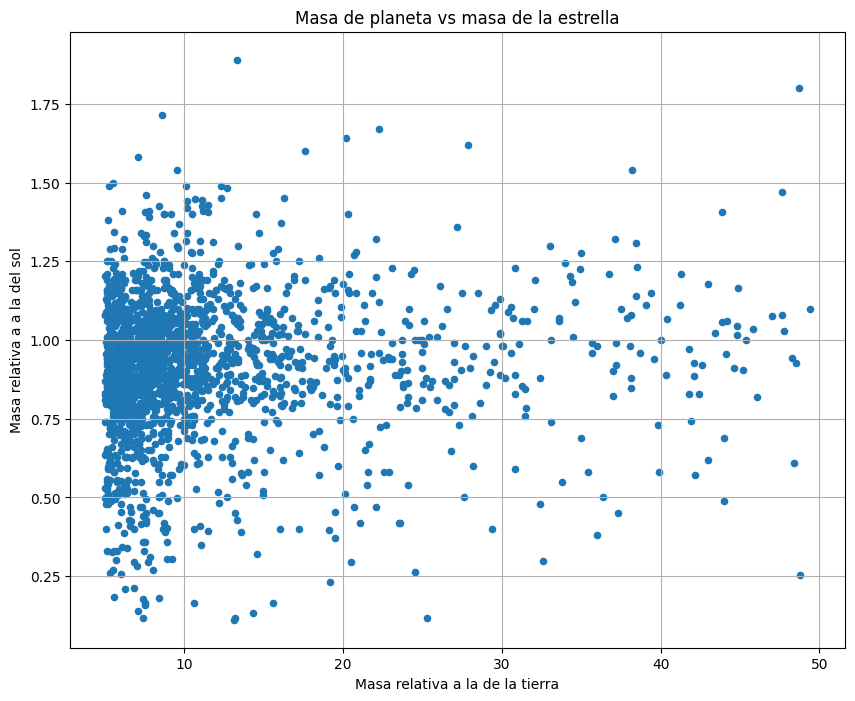

In [62]:
plt.figure(figsize=(10, 8))
plt.scatter(gas_mas['pl_bmasse'], gas_mas['st_mass'], s=20, alpha=1)
plt.title("Masa de planeta vs masa de la estrella")
plt.xlabel("Masa relativa a la de la tierra")
plt.ylabel("Masa relativa a a la del sol")
plt.grid(True)
plt.show()

##BOXPLOTS

Por último hacemos los boxplots

In [63]:
# definimos una función que clasifique las estrellas en función de su temperatura y cree una columan nueva en el dataframe para añadir esos datos
def classify_star_type(teff):
    if teff >= 30000:
        return 'O'
    elif teff >= 10000:
        return 'B'
    elif teff >= 7500:
        return 'A'
    elif teff >= 6000:
        return 'F'
    elif teff >= 5200:
        return 'G'
    elif teff >= 3700:
        return 'K'
    elif teff >= 2400:
        return 'M'
    else:
        return 'Unknown'

df1['star_type'] = df1['st_teff'].apply(classify_star_type)
display(df1.head())

,pl_name,pl_orbper,pl_rade,pl_bmasse,st_teff,st_rad,st_mass,star_type
0,CoRoT-10 b,13.240600,10.87,874.000,5075.0,0.790,0.890,K
1,CoRoT-11 b,2.994330,16.03,740.510,6440.0,1.370,1.270,F
2,CoRoT-13 b,4.035190,9.92,415.704,5945.0,1.010,1.090,G
3,CoRoT-12 b,2.828042,16.14,291.438,5675.0,1.116,1.078,G
4,CoRoT-14 b,1.512140,12.22,2415.400,6035.0,1.210,1.130,F


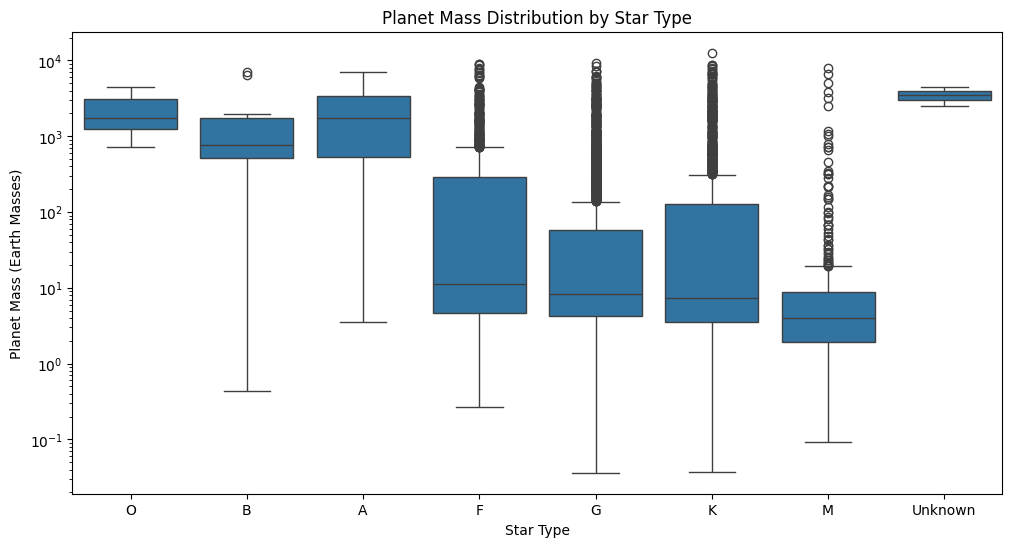

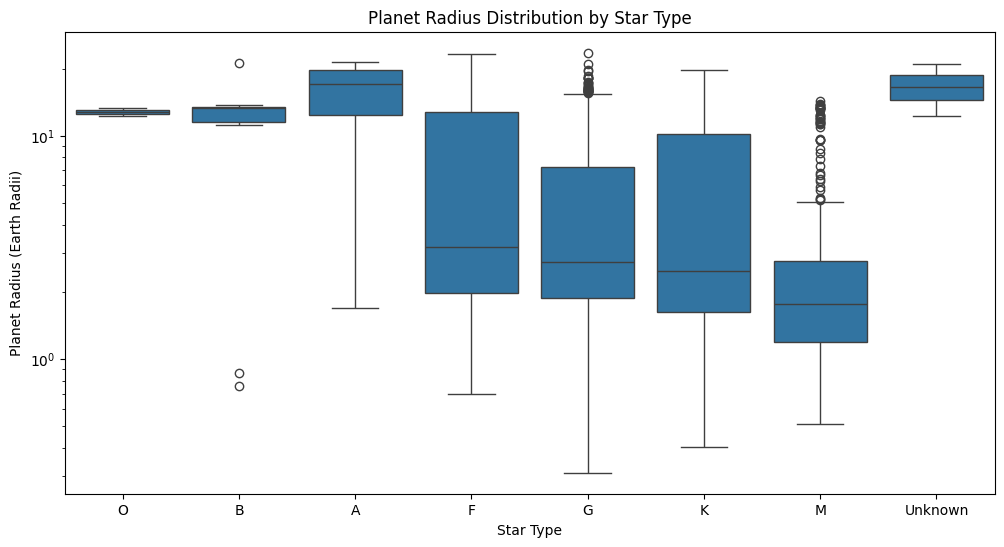

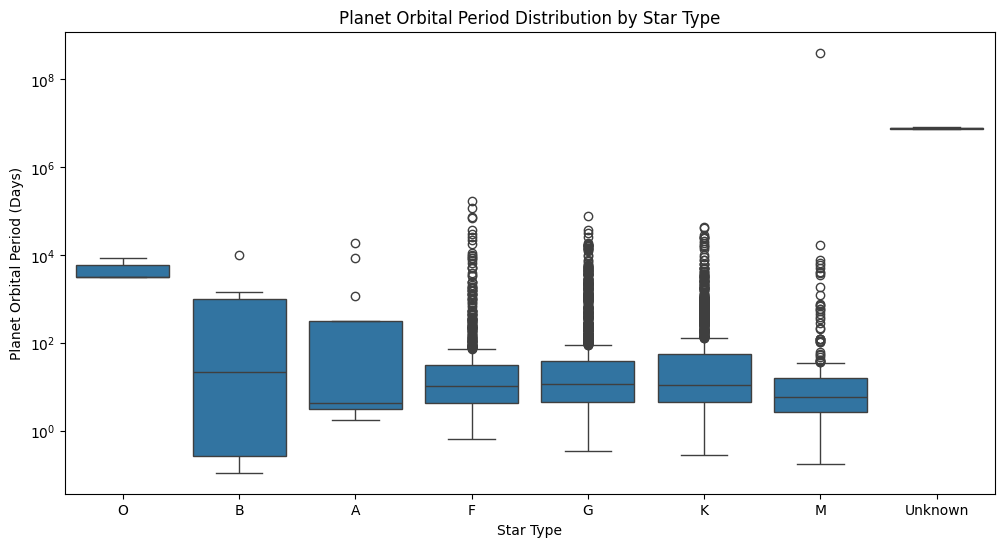

In [64]:
#boxplots para planetas por masa
plt.figure(figsize=(12, 6))
sns.boxplot(x='star_type', y='pl_bmasse', data=df1, order=['O', 'B', 'A', 'F', 'G', 'K', 'M', 'Unknown'])
plt.title('Planet Mass Distribution by Star Type')
plt.xlabel('Star Type')
plt.ylabel('Planet Mass (Earth Masses)')
plt.yscale('log') # Usamos logaritmos para visualizar mejor los datos
plt.show()

#boxplots para planetas por tipo de estrella
plt.figure(figsize=(12, 6))
sns.boxplot(x='star_type', y='pl_rade', data=df1, order=['O', 'B', 'A', 'F', 'G', 'K', 'M', 'Unknown'])
plt.title('Planet Radius Distribution by Star Type')
plt.xlabel('Star Type')
plt.ylabel('Planet Radius (Earth Radii)')
plt.yscale('log')
plt.show()

# Boxplots para órbita dependiendo de la estrella
plt.figure(figsize=(12, 6))
sns.boxplot(x='star_type', y='pl_orbper', data=df1, order=['O', 'B', 'A', 'F', 'G', 'K', 'M', 'Unknown'])
plt.title('Planet Orbital Period Distribution by Star Type')
plt.xlabel('Star Type')
plt.ylabel('Planet Orbital Period (Days)')
plt.yscale('log') # Use log scale for better visualization of varied periods
plt.show()

In [65]:
report2 = ProfileReport(df1)
report2.to_file("report2.html")
report2

Output hidden; open in https://colab.research.google.com to view.

In [66]:
import pygwalker as pyg
pyg.walk(df1)

Box(children=(HTML(value='\n<div id="ifr-pyg-00064351c744d606HI1ikq3fVLxTlanO" style="height: auto">\n    <hea…

#BLOQUE 3

##QUERY Minor Planet Center

Primero realizamos la query, en este caso cogemos los datos del "minor planet center"

In [67]:
import requests
import json

response = requests.get("https://data.minorplanetcenter.net/api/get-obs", json={"desigs": ["ceres"], "output_format": ["OBS80"]})

if response.ok:
    obs80_string = response.json()[0]['OBS80']
    print(obs80_string)
else:
    print("Error: ", response.status_code, response.content)

00001         A1801 01 01.82630 03 38 23.07 +16 17 25.5                 MC004535
00001         A1801 01 02.82337 03 38 05.84 +16 20 51.5                 MC004535
00001         A1801 01 03.82045 03 37 50.6  +16 24 21.2                 MC004535
00001         A1801 01 04.81755 03 37 35.52 +16 27 50.7                 MC004535
00001         A1801 01 10.80058 03 36 45.9  +16 50 36.9                 MC004535
00001         A1801 01 11.79783 03 36 43.82 +16 55                      MC004535
00001         A1801 01 13.79236 03 36 44.91 +17 02 54.7                 MC004535
00001         A1801 01 14.78965 03 36 46.62 +17 07 10.5                 MC004535
00001         A1801 01 18.77899 03 37 11    +17 25                      MC004535
00001         A1801 01 19.77641 03 37 24.74 +17 29 12.2                 MC004535
00001         A1801 01 21.77126 03 37 51.61 +17 38 25.9                 MC004535
00001         A1801 01 22.76871 03 38 07.15 +17 43 05.0                 MC004535
00001         A1801 01 23.76

En la query, la información está compactada en cadenas de texto. Hay que organizar la información en columnas de un dataframe

In [68]:
import pandas as pd
import io
import numpy as np

# nombramos los nombres de las columnas
col_names = [
    'designation', 'method', 'year', 'month', 'day', 'hour', 'minute',
    'ra', 'dec', 'magnitude', 'observatory_code'
]
# registramos de qué caracter a que caracter va cada columna
col_positions = [
    (0, 14),(14, 15), (15, 20), (21, 23), (23, 25), (25, 31), (35, 37),
    (31, 44), (45, 58), (65, 70), (70, 80)
]
obs80_io = io.StringIO(obs80_string)

# transformamos el formato horario
obs80_df = pd.read_fwf(obs80_io, colspecs=col_positions, names=col_names, header=None)
obs80_df['hour'] = obs80_df['hour'] * 24

obs80_df['minute']=(obs80_df['hour']-obs80_df['hour'].apply(np.floor))*60

obs80_df['hour']=obs80_df['hour'].apply(np.floor)
obs80_df['hour'] = obs80_df['hour'].astype(int)

#mostramos el dataframe y la información que contiene
display(obs80_df.head())
print(obs80_df)


obs80_df.info()

,designation,method,year,month,day,hour,minute,ra,dec,magnitude,observatory_code
0,00001,A,1801,1,1,19,49.8720,03 38 23.07,16 17 25.5,NaN,MC004535
1,00001,A,1801,1,2,19,45.6528,03 38 05.84,16 20 51.5,NaN,MC004535
2,00001,A,1801,1,3,19,41.4480,03 37 50.6,16 24 21.2,NaN,MC004535
3,00001,A,1801,1,4,19,37.2720,03 37 35.52,16 27 50.7,NaN,MC004535
4,00001,A,1801,1,10,19,12.8352,03 36 45.9,16 50 36.9,NaN,MC004535


     designation method  year  month  day  hour   minute            ra  \
0          00001      A  1801      1    1    19  49.8720   03 38 23.07   
1          00001      A  1801      1    2    19  45.6528   03 38 05.84   
2          00001      A  1801      1    3    19  41.4480    03 37 50.6   
3          00001      A  1801      1    4    19  37.2720   03 37 35.52   
4          00001      A  1801      1   10    19  12.8352    03 36 45.9   
...          ...    ...   ...    ...  ...   ...      ...           ...   
8262       00001      C  2025      0    3    20  41.9712   00 56 47.03   
8263       00001      C  2025      0    3    21  18.0144   00 56 45.71   
8264       00001      C  2025      0    3    21  29.3184   00 56 45.15   
8265       00001      C  2025      1    3    11  46.0464  00 33 32.832   
8266       00001      C  2025      1    3    12  16.1136  00 33 32.069   

              dec  magnitude observatory_code  
0      16 17 25.5        NaN         MC004535  
1      16 20 51

La información relativa del dataframe:

In [69]:
# hacemos una copia del dataframe para manipular los datos
df4= obs80_df.copy()
df4.describe()

,year,month,day,hour,minute,magnitude
count,8267.000000,8267.000000,8267.000000,8267.000000,8267.000000,1601.000000
mean,1967.131487,3.699528,15.790976,12.479255,28.938535,697.469307
std,38.650465,2.864925,8.839954,8.583398,17.721813,2022.873780
min,1801.000000,0.000000,1.000000,0.000000,0.000000,2.650000
25%,1956.000000,1.000000,8.000000,3.000000,13.588800,7.820000
50%,1970.000000,3.000000,16.000000,16.000000,28.617600,8.480000
75%,1988.000000,6.000000,23.000000,20.500000,44.239200,9.400000
max,2025.000000,9.000000,31.000000,23.000000,59.995200,9886.000000


In [70]:
df4.head(10)

,designation,method,year,month,day,hour,minute,ra,dec,magnitude,observatory_code
0,00001,A,1801,1,1,19,49.8720,03 38 23.07,16 17 25.5,NaN,MC004535
1,00001,A,1801,1,2,19,45.6528,03 38 05.84,16 20 51.5,NaN,MC004535
2,00001,A,1801,1,3,19,41.4480,03 37 50.6,16 24 21.2,NaN,MC004535
3,00001,A,1801,1,4,19,37.2720,03 37 35.52,16 27 50.7,NaN,MC004535
4,00001,A,1801,1,10,19,12.8352,03 36 45.9,16 50 36.9,NaN,MC004535
5,00001,A,1801,1,11,19,8.8752,03 36 43.82,16 55,NaN,MC004535
6,00001,A,1801,1,13,19,0.9984,03 36 44.91,17 02 54.7,NaN,MC004535
7,00001,A,1801,1,14,18,57.0960,03 36 46.62,17 07 10.5,NaN,MC004535
8,00001,A,1801,1,18,18,41.7456,03 37 11,17 25,NaN,MC004535
9,00001,A,1801,1,19,18,38.0304,03 37 24.74,17 29 12.2,NaN,MC004535


In [71]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8267 entries, 0 to 8266
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   designation       8267 non-null   object 
 1   method            7520 non-null   object 
 2   year              8267 non-null   int64  
 3   month             8267 non-null   int64  
 4   day               8267 non-null   int64  
 5   hour              8267 non-null   int64  
 6   minute            8267 non-null   float64
 7   ra                8267 non-null   object 
 8   dec               8267 non-null   object 
 9   magnitude         1601 non-null   float64
 10  observatory_code  8267 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 710.6+ KB


In [72]:
df4 = df4.dropna()
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1461 entries, 444 to 8266
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   designation       1461 non-null   object 
 1   method            1461 non-null   object 
 2   year              1461 non-null   int64  
 3   month             1461 non-null   int64  
 4   day               1461 non-null   int64  
 5   hour              1461 non-null   int64  
 6   minute            1461 non-null   float64
 7   ra                1461 non-null   object 
 8   dec               1461 non-null   object 
 9   magnitude         1461 non-null   float64
 10  observatory_code  1461 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 137.0+ KB


El mapa de correlación de variables:

<Axes: >

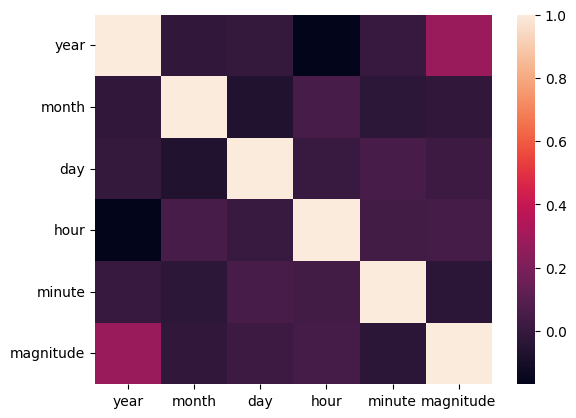

In [73]:
sns.heatmap(df4.select_dtypes([np.number]).corr())

La correlación más fuerte es entre magnitud aparente y año. Esto tiene sentido por la siguiente razón: Ceres se encuentra en el cinturón de asteroides y su órbita dura más que la de la tierra, por lo que no siempre están a la misma distancia. La magnitud es inversamente proporcional a la distancia entre objetos

Vamos a convertir lasunidades de ca y decde grados sexagesimales a decimales y representarlos en coordenads polares

In [74]:
def sexagesimal_to_decimal(coord_str):
    """Converts a sexagesimal coordinate string (like 'HH MM SS.S' or 'DD MM SS.S') to decimal degrees."""
    parts = coord_str.split()
    if len(parts) not in [2, 3]:
        return np.nan  # Handle unexpected formats

    try:
        degrees = float(parts[0])
        minutes = float(parts[1]) if len(parts) > 1 else 0
        seconds = float(parts[2]) if len(parts) > 2 else 0

        decimal_degrees = abs(degrees) + minutes / 60 + seconds / 3600
        if degrees < 0:
            decimal_degrees *= -1
        return decimal_degrees
    except ValueError:
        return np.nan # Gestiona los casos en los que la conversión a float falla

#Aplica los cambos y crea columnas nuevas en el dataframe
df4['ra_deg'] = df4['ra'].apply(sexagesimal_to_decimal)
df4['dec_deg'] = df4['dec'].apply(sexagesimal_to_decimal)

#Convierte los datos de RA a radianes para crear una representación  polar
df4['ra_rad'] = np.radians(df4['ra_deg'])

# Muestra el dataframe con las columnas de datos nuevas
display(df4.head())

,designation,method,year,month,day,hour,minute,ra,dec,magnitude,observatory_code,ra_deg,dec_deg,ra_rad
444,00001,M,1899,4,20,21,5.9760,14 32 53.12,01 46 57.0,7.2,VpAN156135,14.548089,1.782500,0.253912
445,00001,M,1899,4,28,20,41.7696,14 25 43.95,01 34 14.0,7.0,VpAN150030,14.428875,1.570556,0.251831
497,00001,M,1903,1,16,22,50.6352,10 21 11.57,24 32 43.2,6.9,VpAN166015,10.353214,24.545333,0.180698
502,00001,M,1903,1,23,22,38.8992,10 17 43.87,25 32 11.6,6.8,VpAN166015,10.295519,25.536556,0.179691
505,00001,M,1903,2,2,21,5.6880,10 10 46.86,26 56 26.8,6.9,VpAN166015,10.179683,26.940778,0.177669


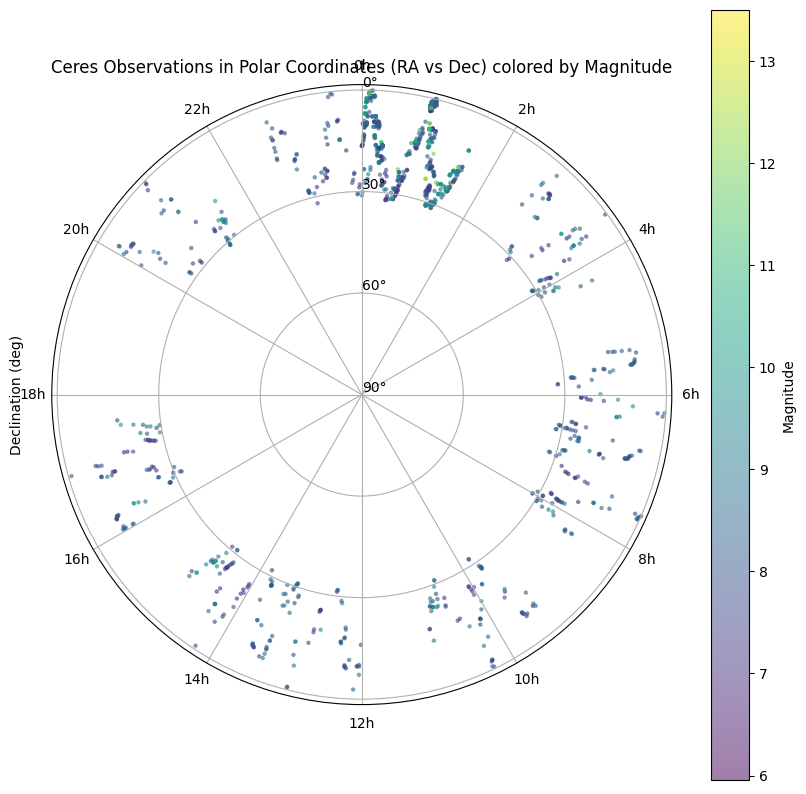

In [75]:
# Crear un plot polar
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

# Ploteamos los datos, usando la declinación como coordenada radial (distancia al polo)
# Nota: En representaciones polares astronómicas, 90 grados es el polo norte, -90 grados es el polo sur
# Los datos se representan usando el polo norte como centro de coordeandas
scatter = ax.scatter(df4['ra_rad'], 90 - df4['dec_deg'], c=df4['magnitude'], cmap='viridis', s=5, alpha=0.5)

ax.set_theta_zero_location("N")  # Poner el norte a 0 grados
ax.set_theta_direction(-1) # Marca los datos en sentido horario

ax.set_rlabel_position(0)
# Etiquetas para el eje radial (Declinación)
ax.set_yticks(np.arange(0, 91, 30))
ax.set_yticklabels([f'{90 - deg}°' for deg in np.arange(0, 91, 30)])
ax.set_ylabel('Declination (deg)', labelpad=20)# añadir una etiqueta para el eje radial

# Etiquetas para el eje angular (Ascensión Recta)
# Convertir radianes a horas para el display (2pi radianes = 24 horas)
ax.set_xticks(np.radians(np.arange(0, 360, 30)))
ax.set_xticklabels([f'{int(deg/15)}h' for deg in np.arange(0, 360, 30)]) # Etiquetas en horas

# Añade una barra de color para la magnitud
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Magnitude')


plt.title('Ceres Observations in Polar Coordinates (RA vs Dec) colored by Magnitude', va='bottom')
plt.show()

Para poder calcular todo lo necesario para hacer las simulaciones, es necesario saber en qué lugares se tomaron las medidas. Estos datos se encuentran en https://www.minorplanetcenter.net/data . Descargamos los datos del json y los convertimos en CSV en local. Después subimos el nevo CSV a drive para trbajarlo en colaboratory:

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [77]:
path = '/content/drive/My Drive/Colab Notebooks/Comp_AV/archivos_CSV/'

In [78]:
import os

print(os.listdir(path))

['base_datos_2008.csv', 'hipparcos-voidmain.csv', 'piedra_papel_tijera_results.csv', 'subvenciones.csv', 'subvenciones.json', 'subvenciones.xls', 'serie_historica_acumulados 21.05.2020.csv', 'q1_q17_dr25_tce_2025.09.23_03.31.23.csv', 'exoplanetas.csv', 'kepler_2025.09.23.csv', 'Meteorite_Landings.csv', 'heart.csv', 'obscodes_extended.csv']


In [79]:
import pandas as pd
df = pd.read_csv(path +'obscodes_extended.csv')

La inforación relevante del dataframe:

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2659 entries, 0 to 2658
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Code       2659 non-null   object 
 1   Longitude  2637 non-null   float64
 2   cos        2637 non-null   float64
 3   sin        2637 non-null   float64
 4   Name       2659 non-null   object 
dtypes: float64(3), object(2)
memory usage: 104.0+ KB


In [81]:
df.head()

,Code,Longitude,cos,sin,Name
0,000,0.0000,0.62411,0.77873,Greenwich
1,001,0.1542,0.62992,0.77411,Crowborough
2,002,0.6200,0.62200,0.78100,Rayleigh
3,003,3.9000,0.72500,0.68700,Montpellier
4,004,1.4625,0.72520,0.68627,Toulouse


Necesitamos asociar los datos del dataframe original con los del nuevo. Para ello usamos los últimos 3 dígitos de la columna "obsevatory code" que es el código de observatorio, que es la 1ª columna en el dataframe nuevo:

In [82]:
df4['observatory_code_short'] = df4['observatory_code'].str[-3:]
merged_df_partial = pd.merge(df4, df, left_on='observatory_code_short', right_on='Code', how='left')
display(merged_df_partial.head())

,designation,method,year,month,day,hour,minute,ra,dec,magnitude,observatory_code,ra_deg,dec_deg,ra_rad,observatory_code_short,Code,Longitude,cos,sin,Name
0,00001,M,1899,4,20,21,5.9760,14 32 53.12,01 46 57.0,7.2,VpAN156135,14.548089,1.782500,0.253912,135,135,49.12100,0.563530,0.823340,Kasan
1,00001,M,1899,4,28,20,41.7696,14 25 43.95,01 34 14.0,7.0,VpAN150030,14.428875,1.570556,0.251831,030,030,11.25446,0.723534,0.688012,"Arcetri Observatory, Florence"
2,00001,M,1903,1,16,22,50.6352,10 21 11.57,24 32 43.2,6.9,VpAN166015,10.353214,24.545333,0.180698,015,015,5.12929,0.615770,0.785285,Utrecht
3,00001,M,1903,1,23,22,38.8992,10 17 43.87,25 32 11.6,6.8,VpAN166015,10.295519,25.536556,0.179691,015,015,5.12929,0.615770,0.785285,Utrecht
4,00001,M,1903,2,2,21,5.6880,10 10 46.86,26 56 26.8,6.9,VpAN166015,10.179683,26.940778,0.177669,015,015,5.12929,0.615770,0.785285,Utrecht


In [83]:
merged_df_partial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             1461 non-null   object 
 1   method                  1461 non-null   object 
 2   year                    1461 non-null   int64  
 3   month                   1461 non-null   int64  
 4   day                     1461 non-null   int64  
 5   hour                    1461 non-null   int64  
 6   minute                  1461 non-null   float64
 7   ra                      1461 non-null   object 
 8   dec                     1461 non-null   object 
 9   magnitude               1461 non-null   float64
 10  observatory_code        1461 non-null   object 
 11  ra_deg                  1238 non-null   float64
 12  dec_deg                 1237 non-null   float64
 13  ra_rad                  1238 non-null   float64
 14  observatory_code_short  1461 non-null   

Hacemos la copia del dataframe para trabajar con los datos:

In [84]:
mdf = merged_df_partial.copy()

In [85]:
mdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             1461 non-null   object 
 1   method                  1461 non-null   object 
 2   year                    1461 non-null   int64  
 3   month                   1461 non-null   int64  
 4   day                     1461 non-null   int64  
 5   hour                    1461 non-null   int64  
 6   minute                  1461 non-null   float64
 7   ra                      1461 non-null   object 
 8   dec                     1461 non-null   object 
 9   magnitude               1461 non-null   float64
 10  observatory_code        1461 non-null   object 
 11  ra_deg                  1238 non-null   float64
 12  dec_deg                 1237 non-null   float64
 13  ra_rad                  1238 non-null   float64
 14  observatory_code_short  1461 non-null   

Limpiamos los datos de columas nulas:

In [86]:
mdf = mdf.dropna()
mdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1219 entries, 0 to 1460
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   designation             1219 non-null   object 
 1   method                  1219 non-null   object 
 2   year                    1219 non-null   int64  
 3   month                   1219 non-null   int64  
 4   day                     1219 non-null   int64  
 5   hour                    1219 non-null   int64  
 6   minute                  1219 non-null   float64
 7   ra                      1219 non-null   object 
 8   dec                     1219 non-null   object 
 9   magnitude               1219 non-null   float64
 10  observatory_code        1219 non-null   object 
 11  ra_deg                  1219 non-null   float64
 12  dec_deg                 1219 non-null   float64
 13  ra_rad                  1219 non-null   float64
 14  observatory_code_short  1219 non-null   objec

Instalamos librerías necesarias para hacer los cálculos:

In [87]:
%pip install astropy
%pip install poliastro
%pip install SciPY


Necesitamos la latitud de los observatorios:

In [88]:
#Calculamos latitud usando np.arctan2
mdf['latitude'] = np.arctan2(mdf['sin'], mdf['cos'])
# Mostramos dataframe nuevo con la columna
# Display the updated dataframe with the new latitude column
display(mdf.head())

,designation,method,year,month,day,hour,minute,ra,dec,magnitude,...,ra_deg,dec_deg,ra_rad,observatory_code_short,Code,Longitude,cos,sin,Name,latitude
0,00001,M,1899,4,20,21,5.9760,14 32 53.12,01 46 57.0,7.2,...,14.548089,1.782500,0.253912,135,135,49.12100,0.563530,0.823340,Kasan,0.970587
1,00001,M,1899,4,28,20,41.7696,14 25 43.95,01 34 14.0,7.0,...,14.428875,1.570556,0.251831,030,030,11.25446,0.723534,0.688012,"Arcetri Observatory, Florence",0.760238
2,00001,M,1903,1,16,22,50.6352,10 21 11.57,24 32 43.2,6.9,...,10.353214,24.545333,0.180698,015,015,5.12929,0.615770,0.785285,Utrecht,0.905804
3,00001,M,1903,1,23,22,38.8992,10 17 43.87,25 32 11.6,6.8,...,10.295519,25.536556,0.179691,015,015,5.12929,0.615770,0.785285,Utrecht,0.905804
4,00001,M,1903,2,2,21,5.6880,10 10 46.86,26 56 26.8,6.9,...,10.179683,26.940778,0.177669,015,015,5.12929,0.615770,0.785285,Utrecht,0.905804


Para calcular valores de la distancia usando el método de Gauss necesitamos modificar los datos de las horas de medición

In [89]:
import numpy as np
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle, get_body_barycentric_posvel
from numpy.linalg import norm
import pandas as pd

# Ensure the 'hour' column from the original parsing is numeric and handle errors
mdf['hour'] = pd.to_numeric(mdf['hour'], errors='coerce')

# Filter out rows where the original parsed 'hour' is NaN or outside the valid range [0, 23]
mdf = mdf[mdf['hour'].between(0, 23)].copy()

print(f"Number of rows after filtering invalid original hours: {len(mdf)}")


# Pasamos nuestros datos temporales a otro formato para que sea más fácil de estudiar
minute_int = np.floor(mdf['minute']).astype(int)
second = (mdf['minute'] - minute_int) * 60.0

timestamps = pd.to_datetime({
    "year":  mdf['year'].astype(int),
    "month": mdf['month'].astype(int),
    "day":   mdf['day'].astype(int),
    "hour":  mdf['hour'].astype(int),
    "minute": minute_int,
    "second": second
}, utc=True, errors='coerce')

# Filter the DataFrame based on valid timestamps
mdf = mdf[timestamps.notna()].copy()
times = Time(timestamps[timestamps.notna()])  # UTC

ra_hms = mdf['ra'].str.split(expand=True)
dec_dms = mdf['dec'].str.split(expand=True)

# Ensure the hour component of RA is treated as an integer string and is valid
ra_hours_str = ra_hms[0].str.lstrip('0')
ra_hours_str = ra_hours_str.replace('', '0') # Replace empty strings with '0' for hours like ' 0 0.00'

# Convert RA hour string to numeric and filter
ra_hours_numeric = pd.to_numeric(ra_hours_str, errors='coerce')
valid_ra_hours_mask = ra_hours_numeric.between(0, 23) & ra_hours_numeric.notna()

# Apply this mask to the DataFrame before creating Angle objects
mdf = mdf[valid_ra_hours_mask].copy()
times = times[valid_ra_hours_mask] # Filter times as well

# Re-extract ra_hms and dec_dms after the additional filtering
ra_hms = mdf['ra'].str.split(expand=True)
dec_dms = mdf['dec'].str.split(expand=True)

# Recreate ra_hours_str from the filtered ra_hms
ra_hours_str = ra_hms[0].str.lstrip('0')
ra_hours_str = ra_hours_str.replace('', '0')


ra_coords = Angle(ra_hours_str + 'h' + ra_hms[1] + 'm' + ra_hms[2] + 's', unit=u.hourangle)
dec_coords = Angle(dec_dms[0] + 'd' + dec_dms[1] + 'm' + dec_dms[2] + 's', unit=u.deg)

coords = SkyCoord(ra=ra_coords, dec=dec_coords, frame='icrs')

print("Prepared 'times' and 'coords' variables.")
print(f"Number of data points after all filtering: {len(mdf)}")

#Usamos el método de Guass para estudiar las distancias
i, j, k = 0, len(times)//2, len(times)-1

t1, t2, t3 = times[i], times[j], times[k]
u1, u2, u3 = coords[i].cartesian.xyz.value, coords[j].cartesian.xyz.value, coords[k].cartesian.xyz.value


R1 = get_body_barycentric_posvel('earth', t1)[0].xyz.to(u.AU).value
R2 = get_body_barycentric_posvel('earth', t2)[0].xyz.to(u.AU).value
R3 = get_body_barycentric_posvel('earth', t3)[0].xyz.to(u.AU).value


def gauss_method(u1, u2, u3, R1, R2, R3, t1, t2, t3):

    tau1 = (t1 - t2).to(u.day).value
    tau3 = (t3 - t2).to(u.day).value


    D0 = np.dot(u1, np.cross(u2, u3))
    D11 = np.dot(np.cross(R1, u2), u3)
    D12 = np.dot(np.cross(R2, u2), u3)
    D13 = np.dot(np.cross(R3, u2), u3)
    D21 = np.dot(np.cross(u1, R1), u3)
    D22 = np.dot(np.cross(u1, R2), u3)
    D23 = np.dot(np.cross(u1, R3), u3)
    D31 = np.dot(u1, np.cross(u2, R1))
    D32 = np.dot(u1, np.cross(u2, R2))
    D33 = np.dot(u1, np.cross(u2, R3))

    A = (D21*tau3 - D31*tau1)/D0
    B = (D11*tau3 - D31*tau1)/D0

    a = A
    b = B
    c = norm(R2)**2 - 2*np.dot(R2, u2) + 1

    rho2 = np.roots([a, b, c])
    rho2 = np.real(rho2[np.where(rho2 > 0)][0])

    rho1 = (D11 + D21*rho2) / D0
    rho3 = (D13 + D33*rho2) / D0

    return rho1, rho2, rho3

rho1, rho2, rho3 = gauss_method(u1, u2, u3, R1, R2, R3, t1, t2, t3)

print("Initial distances (AU):")
print("ρ1 =", rho1)
print("ρ2 =", rho2)
print("ρ3 =", rho3)

r1 = R1 + rho1*u1
r2 = R2 + rho2*u2
r3 = R3 + rho3*u3

print("\nHeliocentric position at time 2 (AU):")
print(r2)

Number of rows after filtering invalid original hours: 1219
Prepared 'times' and 'coords' variables.
Number of data points after all filtering: 501
Initial distances (AU):
ρ1 = 0.5194220862344089
ρ2 = 2.7326770698816e-06
ρ3 = -0.9642057773576604

Heliocentric position at time 2 (AU):
[-0.87066279  0.43487215  0.18846232]


/usr/local/lib/python3.12/dist-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 103 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/usr/local/lib/python3.12/dist-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/usr/local/lib/python3.12/dist-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/usr/local/lib/python3.12/dist-packages/erfa/core.py:133: ErfaWarning: ERFA function "epv00" yielded 1 of "warning: date outsidethe range 1900-2100 AD"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


Para que el método de Gauss funcione, necesitamos saber al menos 3 distancias

In [90]:
import plotly.graph_objects as go
import numpy as np
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel
from numpy.linalg import norm
#Gráficamos nuestros datos acorde con el método de Gauss

earth_pos1 = get_body_barycentric_posvel('earth', t1)[0].xyz.to(u.AU).value
earth_pos2 = get_body_barycentric_posvel('earth', t2)[0].xyz.to(u.AU).value
earth_pos3 = get_body_barycentric_posvel('earth', t3)[0].xyz.to(u.AU).value


fig = go.Figure()


fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=10, color='yellow'),
    name='Sun'
))

fig.add_trace(go.Scatter3d(
    x=[r1[0], r2[0], r3[0]],
    y=[r1[1], r2[1], r3[1]],
    z=[r1[2], r2[2], r3[2]],
    mode='markers+lines',
    marker=dict(size=5, color='blue'),
    name='Object Positions'
))

fig.add_trace(go.Scatter3d(
    x=[earth_pos1[0], earth_pos2[0], earth_pos3[0]],
    y=[earth_pos1[1], earth_pos2[1], earth_pos3[1]],
    z=[earth_pos1[2], earth_pos2[2], earth_pos3[2]],
    mode='markers+lines',
    marker=dict(size=5, color='green'),
    name='Earth Positions'
))


fig.update_layout(
    title='Object and Earth Positions (Heliocentric)',
    scene = dict(
        xaxis_title='X (AU)',
        yaxis_title='Y (AU)',
        zaxis_title='Z (AU)'),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

Llegados a este punto, cambiamos la query de minor planet center a JPL Horions porque usar el método de Gauss supondría demasiado tiempo de computación.

##QUERY JPL horizons

In [91]:
from astroquery.jplhorizons import Horizons
import astropy.units as u
from astropy.time import Time
import pandas as pd


times_jd = times.jd


observations = {
    'time': times_jd,
    'RA': coords.ra.deg,
    'DEC': coords.dec.deg,
    'Site': mdf['observatory_code'].values.tolist()
}


obj = Horizons(id='A899 OF', location='@sun', epochs=times)


print("Prepared observations data for Horizons.")

Prepared observations data for Horizons.


usamos los datos de la query para calcular posición y velocidad

In [92]:
from astroquery.jplhorizons import Horizons
import astropy.units as u
from astropy.time import Time
import pandas as pd
import numpy as np

#Usamos JPL Horizons para obtener nuestros datos a gráficar

print("Querying JPL Horizons for the state vector of Ceres.")


epoch_for_state_vector = times[len(times)//2]


obj_state_vector = Horizons(id='Ceres', location='@sun', epochs=epoch_for_state_vector.jd)


state_vector_data = obj_state_vector.vectors()


position_vector = np.array([state_vector_data['x'][0], state_vector_data['y'][0], state_vector_data['z'][0]]) * state_vector_data['x'].unit
velocity_vector = np.array([state_vector_data['vx'][0], state_vector_data['vy'][0], state_vector_data['vz'][0]]) * state_vector_data['vx'].unit


print("\nState Vector obtained from JPL Horizons (Heliocentric Ecliptic J2000.0):")
print("Position (AU):", position_vector.to(u.AU))
print("Velocity (AU/d):", velocity_vector.to(u.AU/u.day))

Querying JPL Horizons for the state vector of Ceres.

State Vector obtained from JPL Horizons (Heliocentric Ecliptic J2000.0):
Position (AU): [ 1.00276789  2.53788918 -0.10575125] AU
Velocity (AU/d): [-0.00983075  0.00307866  0.00190759] AU / d


Con los datos creamos una órbita

In [93]:
from poliastro.bodies import Sun
from poliastro.twobody import Orbit
from astropy import units as u
import numpy as np
import plotly.graph_objects as go

#Creamos la órbita de ceres y la Tierra

orbit = Orbit.from_vectors(Sun, position_vector, velocity_vector, epoch=epoch_for_state_vector)

print("Orbit defined using the state vector.")
print(orbit)

n_points = 300

times_to_propagate = epoch_for_state_vector + np.linspace(0, 4.6 * u.year, n_points)


propagated_positions = []
for t in times_to_propagate:

    time_of_flight = t - orbit.epoch

    propagated_orbit_at_t = orbit.propagate(time_of_flight)

    position_at_t = propagated_orbit_at_t.r.to(u.AU).value
    propagated_positions.append(position_at_t)

propagated_positions = np.array(propagated_positions)

print(f"Propagated orbit and generated {len(propagated_positions)} points.")

Orbit defined using the state vector.
3 x 3 AU x 10.6 deg orbit around Sun (☉)
Propagated orbit and generated 300 points.


Por último usamos los datos para crear el plot de la órbita

In [94]:
import plotly.graph_objects as go
import numpy as np
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import get_body_barycentric_posvel

#Animamos la órbita de Ceres y la Tierra
earth_positions_for_animation = []
for t in times_to_propagate:
    earth_pos = get_body_barycentric_posvel('earth', t)[0].xyz.to(u.AU).value
    earth_positions_for_animation.append(earth_pos)

earth_positions_for_animation = np.array(earth_positions_for_animation)



fig = go.Figure(
    data=[
        go.Scatter3d(
            x=[0], y=[0], z=[0],
            mode='markers',
            marker=dict(size=8, color='black'),
            name='Solar System Barycenter'
        ),
        go.Scatter3d(
            x=[0], y=[0], z=[0],
            mode='markers',
            marker=dict(size=10, color='yellow'),
            name='Sun'
        ),
        go.Scatter3d(
            x=propagated_positions[:, 0],
            y=propagated_positions[:, 1],
            z=propagated_positions[:, 2],
            mode='lines',
            line=dict(color='blue', width=2),
            name='Ceres Orbit'
        ),
         go.Scatter3d(
            x=earth_positions_for_animation[:, 0],
            y=earth_positions_for_animation[:, 1],
            z=earth_positions_for_animation[:, 2],
            mode='lines',
            line=dict(color='green', width=2),
            name='Earth Orbit Path'
        ),

         go.Scatter3d(
             x=[propagated_positions[0, 0]], y=[propagated_positions[0, 1]], z=[propagated_positions[0, 2]],
             mode='markers',
             marker=dict(color='red', size=5),
             name='Ceres (Animated)'
         ),
         go.Scatter3d(
             x=[earth_positions_for_animation[0, 0]], y=[earth_positions_for_animation[0, 1]], z=[earth_positions_for_animation[0, 2]],
             mode='markers',
             marker=dict(color='orange', size=5),
             name='Earth (Animated)'
         )],
    layout=go.Layout(
        scene=dict(
            xaxis=dict(title='X (AU)'),
            yaxis=dict(title='Y (AU)'),
            zaxis=dict(title='Z (AU)'),
            aspectmode='cube'
        ),
        title='Animated Orbit of Ceres (with SSB)',
        updatemenus=[dict(
            type="buttons",
            buttons=[dict(label="Play",
                          method="animate",
                          args=[None, {"frame": {"duration": 50, "redraw": True},
                                       "fromcurrent": True, "transition": {"duration": 0,
                                                                           "easing": "linear"}}])])]
    ),
    frames=[go.Frame(
        data=[
            go.Scatter3d( # Solar System Barycenter (static)
                x=[0], y=[0], z=[0],
                mode='markers',
                marker=dict(size=8, color='black'),
            ),
            go.Scatter3d( # Sun (static)
                x=[0], y=[0], z=[0],
                mode='markers',
                marker=dict(size=10, color='yellow'),
            ),
            go.Scatter3d( # Ceres Orbit Path (static)
                x=propagated_positions[:, 0],
                y=propagated_positions[:, 1],
                z=propagated_positions[:, 2],
                mode='lines',
                line=dict(color='blue', width=2),
            ),
             go.Scatter3d( # Earth Orbit Path (static)
                x=earth_positions_for_animation[:, 0],
                y=earth_positions_for_animation[:, 1],
                z=earth_positions_for_animation[:, 2],
                mode='lines',
                line=dict(color='green', width=2),
            ),
            go.Scatter3d( # Ceres (Animated)
                x=[propagated_positions[k, 0]],
                y=[propagated_positions[k, 1]],
                z=[propagated_positions[k, 2]],
                mode='markers',
                marker=dict(color='red', size=5),
            ),
             go.Scatter3d( # Earth (Animated)
                x=[earth_positions_for_animation[k, 0]],
                y=[earth_positions_for_animation[k, 1]],
                z=[earth_positions_for_animation[k, 2]],
                mode='markers',
                marker=dict(color='orange', size=5),
            )]) for k in range(len(propagated_positions))]
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

#Conclusiones

El trabajo dividido en bloques permite trabajar de forma escalonada los diferentes aspectos que se necesitan para entender como tratar los datos observacionales. El hecho de haber tenido que cambiar de query en el bloque 3 demuestra que mucha de la dificultades tratar con este tipo de datos radica en escoger bien las fuentes. Un buen filtrado de los datos ayuda bastante.
En el bloque 2 lo más desafiante es separa el dataframe para ver los distintos tipos de planetas, ya que las diferencias entre planetas gaseosos y los rocosos son notables